# Detector multiclase de EPP con YOLO

Este notebook entrena y evalua un detector de objetos para EPP/PPE en obras de construccion. Esta preparado para ejecutarse tanto localmente como en Google Colab.

La salida principal no es una etiqueta binaria por imagen, sino detecciones multiclase y un reporte de cumplimiento por persona.

Flujo:

- Usar solo `css-data`, que contiene `train`, `valid` y `test` en formato YOLO.
- Entrenar YOLO sobre las 10 clases del dataset.
- Evaluar con metricas de deteccion como mAP, precision y recall.
- Convertir detecciones en un reporte operativo de cumplimiento.


## 1. Verificacion del entorno

En Colab, esta seccion instala las dependencias necesarias y usa GPU CUDA si esta disponible. Para guardar pesos entre sesiones, activa `USE_GOOGLE_DRIVE = True`.

Localmente, usa el entorno `.venv` del proyecto y guarda resultados en `outputs/`.


In [12]:
from pathlib import Path
import importlib.util
import os
import platform
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
USE_GOOGLE_DRIVE = True

if IN_COLAB:
    packages = ["ultralytics", "kagglehub", "pyyaml"]
    missing = [pkg for pkg in packages if importlib.util.find_spec(pkg.split("==")[0].replace("pyyaml", "yaml")) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

PROJECT_ROOT = Path.cwd()

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_BASE = Path("/content/drive/MyDrive/construction-safety-ppe")
else:
    OUTPUT_BASE = PROJECT_ROOT / "outputs"

OUTPUT_BASE.mkdir(parents=True, exist_ok=True)
YOLO_CONFIG_DIR = OUTPUT_BASE / ".ultralytics"
YOLO_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ["YOLO_CONFIG_DIR"] = str(YOLO_CONFIG_DIR.resolve())

import torch
import ultralytics
from ultralytics import YOLO

print(f"Python: {sys.version.split()[0]} ({platform.system()} {platform.machine()})")
print(f"Colab: {IN_COLAB}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Output base: {OUTPUT_BASE}")
print(f"Ultralytics: {ultralytics.__version__}")
print(f"Torch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Python: 3.12.13 (Linux x86_64)
Colab: True
Project root: /content
Output base: /content/drive/MyDrive/construction-safety-ppe
Ultralytics: 8.4.54
Torch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4


## 2. Preparacion del dataset YOLO

KaggleHub descarga una carpeta que incluye datos, archivos fuente y resultados previos. Para entrenar y evaluar correctamente se usa solo `css-data`.

In [13]:
from pathlib import Path
import yaml
import kagglehub
import pandas as pd

DATASET_HANDLE = "snehilsanyal/construction-site-safety-image-dataset-roboflow"
DOWNLOAD_ROOT = Path(kagglehub.dataset_download(DATASET_HANDLE))
DATASET_ROOT = DOWNLOAD_ROOT / "css-data"

CLASS_NAMES = [
    "Hardhat",
    "Mask",
    "NO-Hardhat",
    "NO-Mask",
    "NO-Safety Vest",
    "Person",
    "Safety Cone",
    "Safety Vest",
    "machinery",
    "vehicle",
]

for split in ["train", "valid", "test"]:
    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"
    if not image_dir.exists() or not label_dir.exists():
        raise FileNotFoundError(f"No existe la estructura YOLO esperada para {split}: {image_dir} / {label_dir}")

OUTPUT_DIR = OUTPUT_BASE / "yolo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_YAML_PATH = OUTPUT_DIR / "ppe_data.yaml"

yolo_data = {
    "path": str(DATASET_ROOT.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": CLASS_NAMES,
}
DATA_YAML_PATH.write_text(yaml.safe_dump(yolo_data, sort_keys=False), encoding="utf-8")

print("Download root:", DOWNLOAD_ROOT)
print("Dataset root usado:", DATASET_ROOT)
print("YOLO data config:", DATA_YAML_PATH)
print(DATA_YAML_PATH.read_text(encoding="utf-8"))

Using Colab cache for faster access to the 'construction-site-safety-image-dataset-roboflow' dataset.
Download root: /kaggle/input/construction-site-safety-image-dataset-roboflow
Dataset root usado: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data
YOLO data config: /content/drive/MyDrive/construction-safety-ppe/yolo/ppe_data.yaml
path: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data
train: train/images
val: valid/images
test: test/images
names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle



## 3. Auditoria especifica para deteccion

Antes de entrenar, valida conteos por split, correspondencia imagen-etiqueta y balance de clases por anotacion.

In [15]:
from collections import Counter

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

split_rows = []
annotation_counter = Counter()
missing_label_files = []
empty_label_files = []
invalid_class_ids = []

for split in ["train", "valid", "test"]:
    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"
    image_paths = sorted(p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
    label_paths = sorted(label_dir.glob("*.txt"))

    for image_path in image_paths:
        label_path = label_dir / f"{image_path.stem}.txt"
        if not label_path.exists():
            missing_label_files.append(str(image_path.relative_to(DATASET_ROOT)))
            continue
        lines = [line.strip() for line in label_path.read_text(encoding="utf-8", errors="ignore").splitlines() if line.strip()]
        if not lines:
            empty_label_files.append(str(label_path.relative_to(DATASET_ROOT)))
        for line_number, line in enumerate(lines, start=1):
            parts = line.split()
            try:
                class_id = int(float(parts[0]))
            except (IndexError, ValueError):
                invalid_class_ids.append((str(label_path.relative_to(DATASET_ROOT)), line_number, line))
                continue
            if class_id < 0 or class_id >= len(CLASS_NAMES):
                invalid_class_ids.append((str(label_path.relative_to(DATASET_ROOT)), line_number, line))
                continue
            annotation_counter[CLASS_NAMES[class_id]] += 1

    split_rows.append(
        {
            "split": split,
            "images": len(image_paths),
            "labels": len(label_paths),
        }
    )

split_df = pd.DataFrame(split_rows)
class_balance_df = pd.DataFrame(
    [{"class_name": name, "annotations": annotation_counter[name]} for name in CLASS_NAMES]
).sort_values("annotations", ascending=False)

print("Conteo por split:")
display(split_df)
print("Balance por clase:")
display(class_balance_df)
print("Imagenes sin label:", len(missing_label_files))
print("Labels vacios:", len(empty_label_files))
print("Lineas con class_id invalido:", len(invalid_class_ids))

Conteo por split:


,split,images,labels
0,train,2605,2605
1,valid,114,114
2,test,82,82


Balance por clase:


,class_name,annotations
5,Person,9872
8,machinery,5346
4,NO-Safety Vest,4158
6,Safety Cone,3502
0,Hardhat,3334
3,NO-Mask,3250
7,Safety Vest,3135
2,NO-Hardhat,2427
1,Mask,1700
9,vehicle,1628


Imagenes sin label: 0
Labels vacios: 24
Lineas con class_id invalido: 0


## 4. Entrenamiento YOLO multiclase

Este es el baseline de deteccion. En CPU puede tardar; para una primera prueba baja `EPOCHS` a 5. Para un resultado mas serio usa GPU y sube `EPOCHS` a 50-100.

In [16]:
MODEL_WEIGHTS = "yolov8n.pt"
EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"
RUN_TRAINING = False  # Baseline already completed; set True only to retrain yolov8n.

if RUN_TRAINING:
    model = YOLO(MODEL_WEIGHTS)
    train_results = model.train(
        data=str(DATA_YAML_PATH),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=DEVICE,
        project=str((OUTPUT_BASE / "yolo_runs").resolve()),
        name="ppe_yolov8n_baseline",
        exist_ok=True,
        patience=10,
        seed=42,
    )
else:
    print("RUN_TRAINING=False. Cambialo a True para entrenar.")

RUN_TRAINING=False. Cambialo a True para entrenar.


## 5. Evaluacion en validacion y test

Para seguridad, mira especialmente el recall de las clases `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`. Esas clases representan condiciones inseguras.

In [17]:
RUN_EVALUATION = True

if RUN_EVALUATION:
    best_model_path = OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline" / "weights" / "best.pt"
    if best_model_path.exists():
        eval_model = YOLO(str(best_model_path))

        print("Validacion baseline:")
        val_metrics = eval_model.val(data=str(DATA_YAML_PATH), split="val", imgsz=IMG_SIZE, device=DEVICE)

        print("Test baseline:")
        test_metrics = eval_model.val(data=str(DATA_YAML_PATH), split="test", imgsz=IMG_SIZE, device=DEVICE)
    else:
        print(f"No se encontro baseline entrenado en {best_model_path}.")
        print("Se omite la evaluacion del baseline. Ejecuta el experimento mejorado o copia best.pt a Drive.")
else:
    print("RUN_EVALUATION=False. Cambialo a True para evaluar.")

Validacion baseline:
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 27.0±11.4 MB/s, size: 63.5 KB)
val: Scanning /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid/labels... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 249.2it/s 0.5s.1s
WARNING ⚠️ val: Cache directory /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.7it/s 4.8s0.4ss
                   all        114        697      0.896      0.681      0.783      0.455
               Hardhat         42         79      0.924      0.747      0.847      0.523
                  Mask         19         21      0.971       0.81      0.907      0.605
           

## 6. Prediccion y reporte de cumplimiento

Esta seccion convierte detecciones en un reporte por persona. Las clases `NO-*` marcan incumplimientos; las cajas se asocian con una persona cuando el centro de la caja cae dentro del bounding box de esa persona.

In [24]:
import sys
from dataclasses import asdict, dataclass
from pprint import pprint
from typing import Iterable

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

try:
    from src.ppe_compliance import Detection, generate_ppe_compliance_report
except ModuleNotFoundError:
    @dataclass(frozen=True)
    class Detection:
        class_name: str
        confidence: float
        box_xyxy: tuple[float, float, float, float]

    def _center_inside(item_box, container_box):
        x1, y1, x2, y2 = item_box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        left, top, right, bottom = container_box
        return left <= cx <= right and top <= cy <= bottom

    def generate_ppe_compliance_report(
        detections: Iterable[Detection],
        *,
        person_class: str = "Person",
        ppe_classes: tuple[str, ...] = ("Hardhat", "Mask", "Safety Vest"),
        violation_classes: tuple[str, ...] = ("NO-Hardhat", "NO-Mask", "NO-Safety Vest"),
        min_confidence: float = 0.25,
    ):
        filtered = [det for det in detections if det.confidence >= min_confidence]
        persons = [det for det in filtered if det.class_name == person_class]
        ppe_items = [det for det in filtered if det.class_name in ppe_classes]
        violations = [det for det in filtered if det.class_name in violation_classes]

        person_reports = []
        assigned_violation_ids = set()
        for person_index, person in enumerate(persons, start=1):
            person_ppe = tuple(sorted({item.class_name for item in ppe_items if _center_inside(item.box_xyxy, person.box_xyxy)}))
            person_violations = tuple(sorted({violation.class_name for violation in violations if _center_inside(violation.box_xyxy, person.box_xyxy)}))
            for violation_id, violation in enumerate(violations):
                if violation.class_name in person_violations and _center_inside(violation.box_xyxy, person.box_xyxy):
                    assigned_violation_ids.add(violation_id)
            person_reports.append(
                {
                    "person_index": person_index,
                    "person_box_xyxy": person.box_xyxy,
                    "detected_ppe": person_ppe,
                    "violations": person_violations,
                    "status": "inseguro" if person_violations else "requiere_revision",
                }
            )

        unassigned_violations = tuple(sorted(violations[index].class_name for index in range(len(violations)) if index not in assigned_violation_ids))
        violation_count = sum(len(person["violations"]) for person in person_reports) + len(unassigned_violations)
        return {
            "status": "inseguro" if violation_count else "sin_violaciones_detectadas",
            "person_count": len(person_reports),
            "violation_count": violation_count,
            "persons": person_reports,
            "unassigned_violations": unassigned_violations,
        }

sample_image = next((DATASET_ROOT / "test" / "images").glob("*.jpg"))
model_path = OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline" / "weights" / "best.pt"

if not model_path.exists():
    print(f"No se encontro baseline entrenado en {model_path}.")
    print("Se omite la prediccion baseline. Ejecuta el experimento mejorado para generar pesos nuevos.")
else:
    predict_model = YOLO(str(model_path))

    results = predict_model.predict(
        source=str(sample_image),
        imgsz=IMG_SIZE,
        conf=0.25,
        device=DEVICE,
        save=True,
        project=str((OUTPUT_BASE / "predictions").resolve()),
        name="sample_compliance",
        exist_ok=True,
    )

    result = results[0]
    detections = []
    for box in result.boxes:
        class_id = int(box.cls.item())
        detections.append(
            Detection(
                class_name=result.names[class_id],
                confidence=float(box.conf.item()),
                box_xyxy=tuple(float(value) for value in box.xyxy[0].tolist()),
            )
        )

    report = generate_ppe_compliance_report(detections)
    print("Imagen:", sample_image)
    print("Detecciones:")
    pprint([asdict(det) for det in detections])
    print("Reporte de cumplimiento:")
    if hasattr(report, "__dataclass_fields__"):
        pprint(asdict(report))
    else:
        pprint(report)


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg: 640x640 2 Persons, 1 Safety Vest, 1 machinery, 7.2ms
Speed: 2.0ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/construction-safety-ppe/predictions/sample_compliance
Imagen: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg
Detecciones:
[{'box_xyxy': (12.76446533203125, 0.0, 637.5701904296875, 633.5013427734375),
  'class_name': 'machinery',
  'confidence': 0.8517130613327026},
 {'box_xyxy': (286.8069763183594,
               247.1194305419922,
               303.2572326660156,
               285.79779052734375),
  'class_name': 'Safety Vest',
  'confidence': 0.779433012008667},
 {'box_xyxy': (267.4818115234375,
               215.68768310546875,
               307.954223632

## 7. Conclusiones del baseline inicial

El primer entrenamiento en Colab uso `yolov8n.pt` durante 50 epocas sobre GPU Tesla T4. El dataset quedo correctamente limitado a `css-data`, con 2,605 imagenes de entrenamiento, 114 de validacion y 82 de test.

Resultados principales:

| split | precision | recall | mAP50 | mAP50-95 |
|---|---:|---:|---:|---:|
| valid | 0.893 | 0.681 | 0.782 | 0.454 |
| test | 0.861 | 0.662 | 0.721 | 0.409 |

Lectura practica:

- El modelo ya es mucho mas util que el clasificador binario porque entrega cajas, clases y causas de incumplimiento.
- La precision global es buena: cuando detecta algo, suele acertar.
- El recall todavia es el punto debil: se le escapan objetos, especialmente infracciones.
- Para una aplicacion de seguridad, hay que priorizar recall en `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`.

Clases criticas en test:

| clase | precision | recall | mAP50 |
|---|---:|---:|---:|
| NO-Hardhat | 0.753 | 0.537 | 0.527 |
| NO-Mask | 0.853 | 0.587 | 0.673 |
| NO-Safety Vest | 0.895 | 0.722 | 0.768 |

Conclusion: el baseline es funcional, pero el siguiente experimento debe intentar subir recall de las clases `NO-*`, empezando por un modelo mas capaz (`yolov8s`) y guardando resultados en Google Drive.

## 8. Artefactos visuales del baseline inicial

Esta celda conserva todos los artefactos visuales del primer entrenamiento, pero solo muestra un resumen para mantener el notebook legible.

Se muestran:

- `results.png`
- `confusion_matrix.png`
- `PR_curve.png`
- `F1_curve.png`
- hasta 2 predicciones de `sample_compliance`
- hasta 3 ejemplos `val_batch*_pred.jpg`

Todos los artefactos encontrados se copian a `baseline_initial_artifacts/` dentro de `OUTPUT_BASE`.

Imagenes encontradas en total: 66
Imagenes mostradas en resumen: 11


Artefactos completos copiados a `/content/drive/MyDrive/construction-safety-ppe/baseline_initial_artifacts`

### Resumen visual mostrado

**results.png**  
`/content/outputs/yolo_runs/ppe_yolov8n_baseline/results.png`

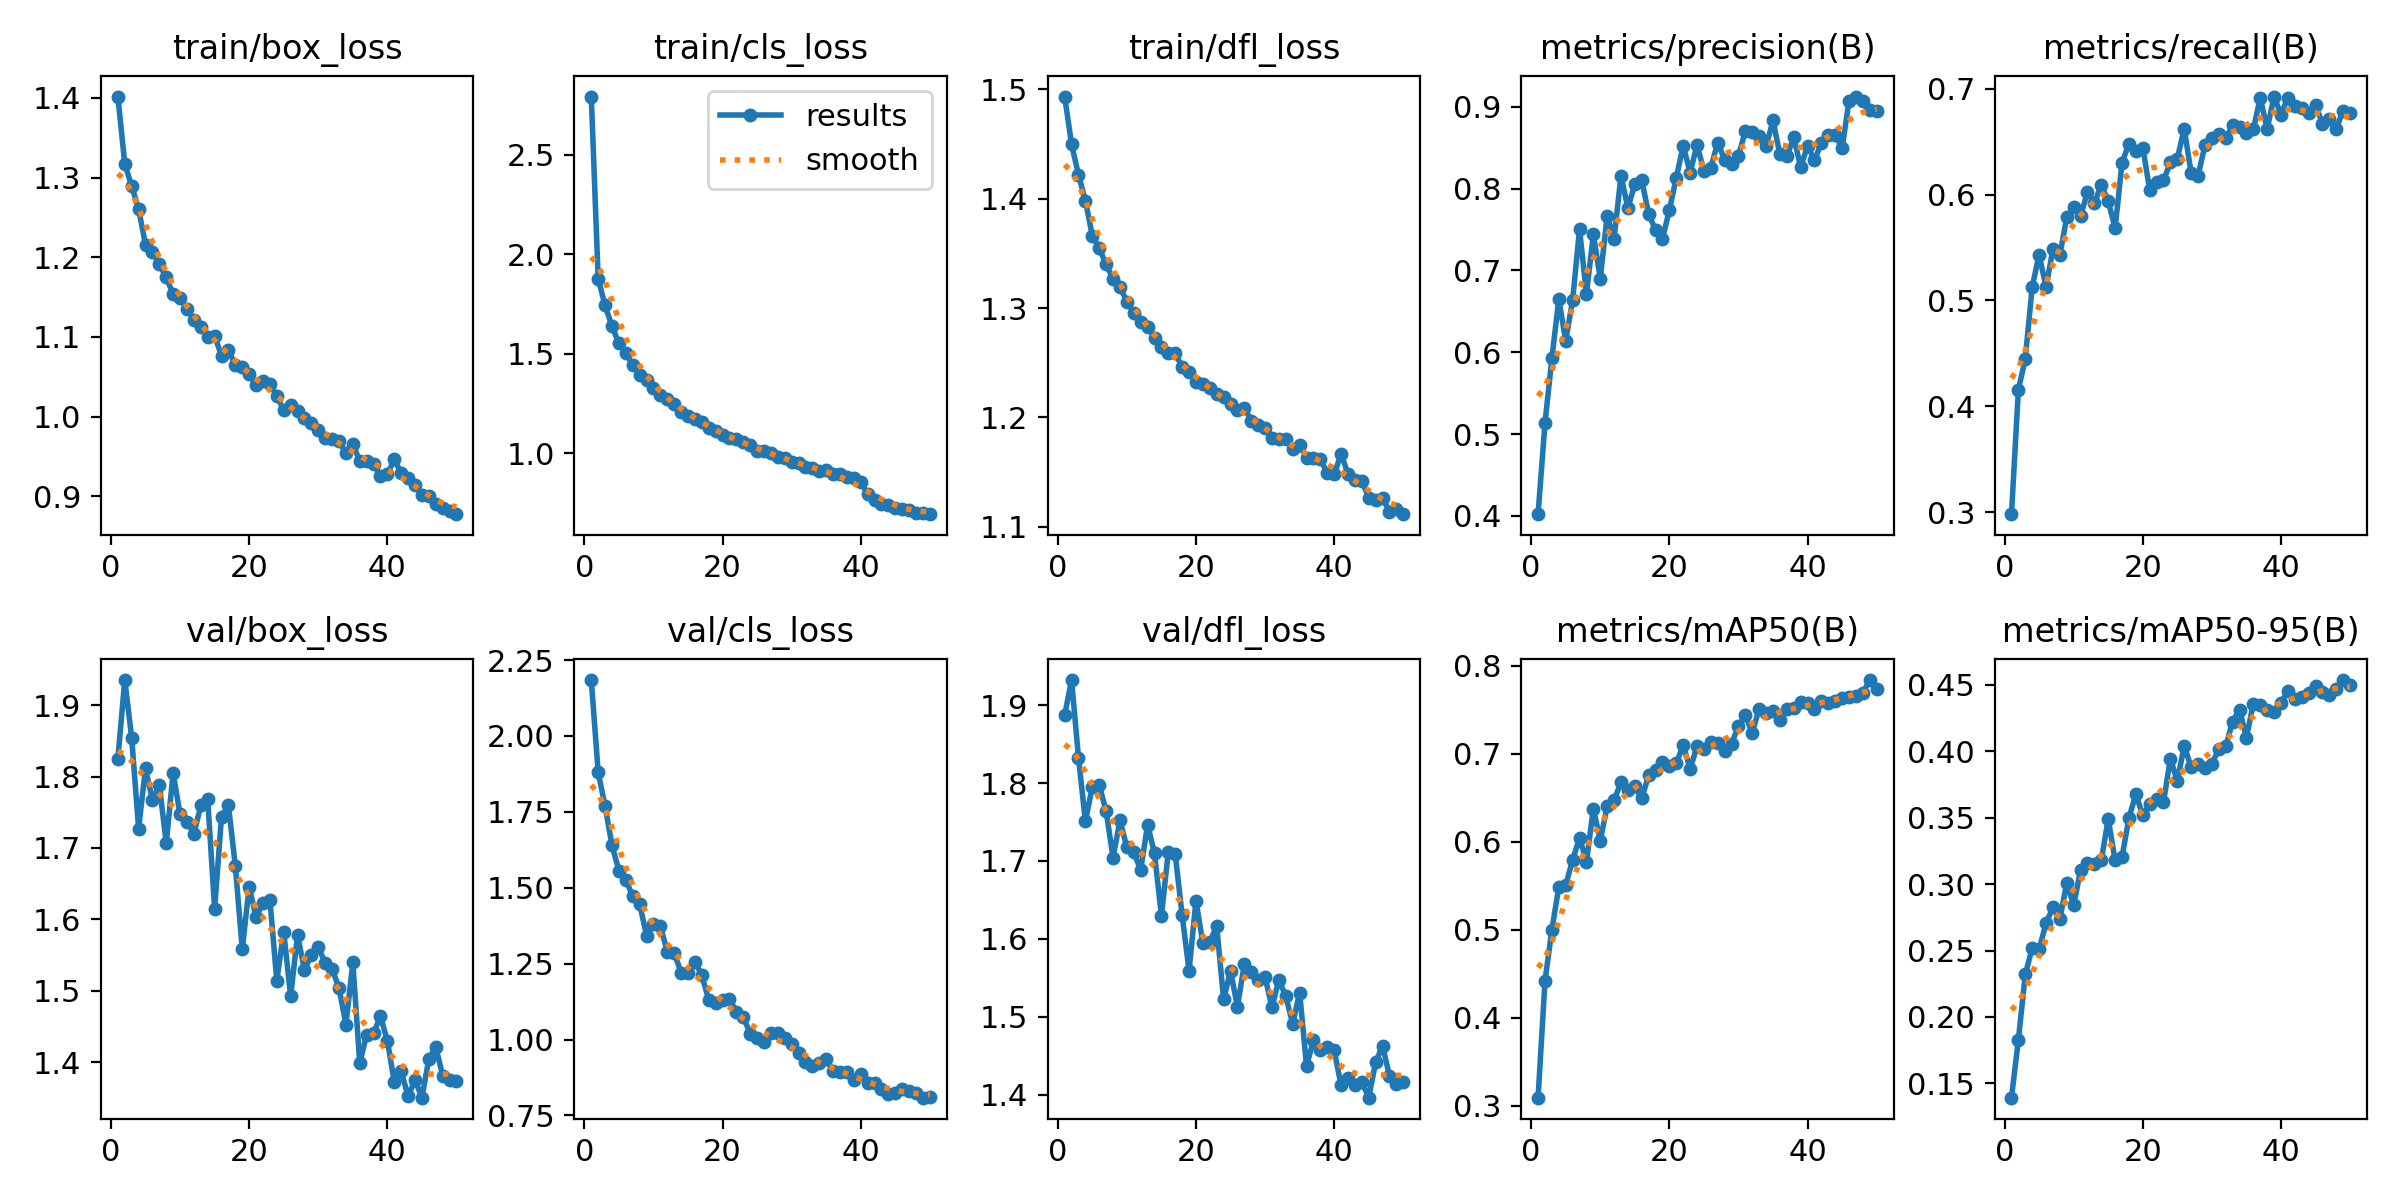

**confusion_matrix.png**  
`/content/outputs/yolo_runs/ppe_yolov8n_baseline/confusion_matrix.png`

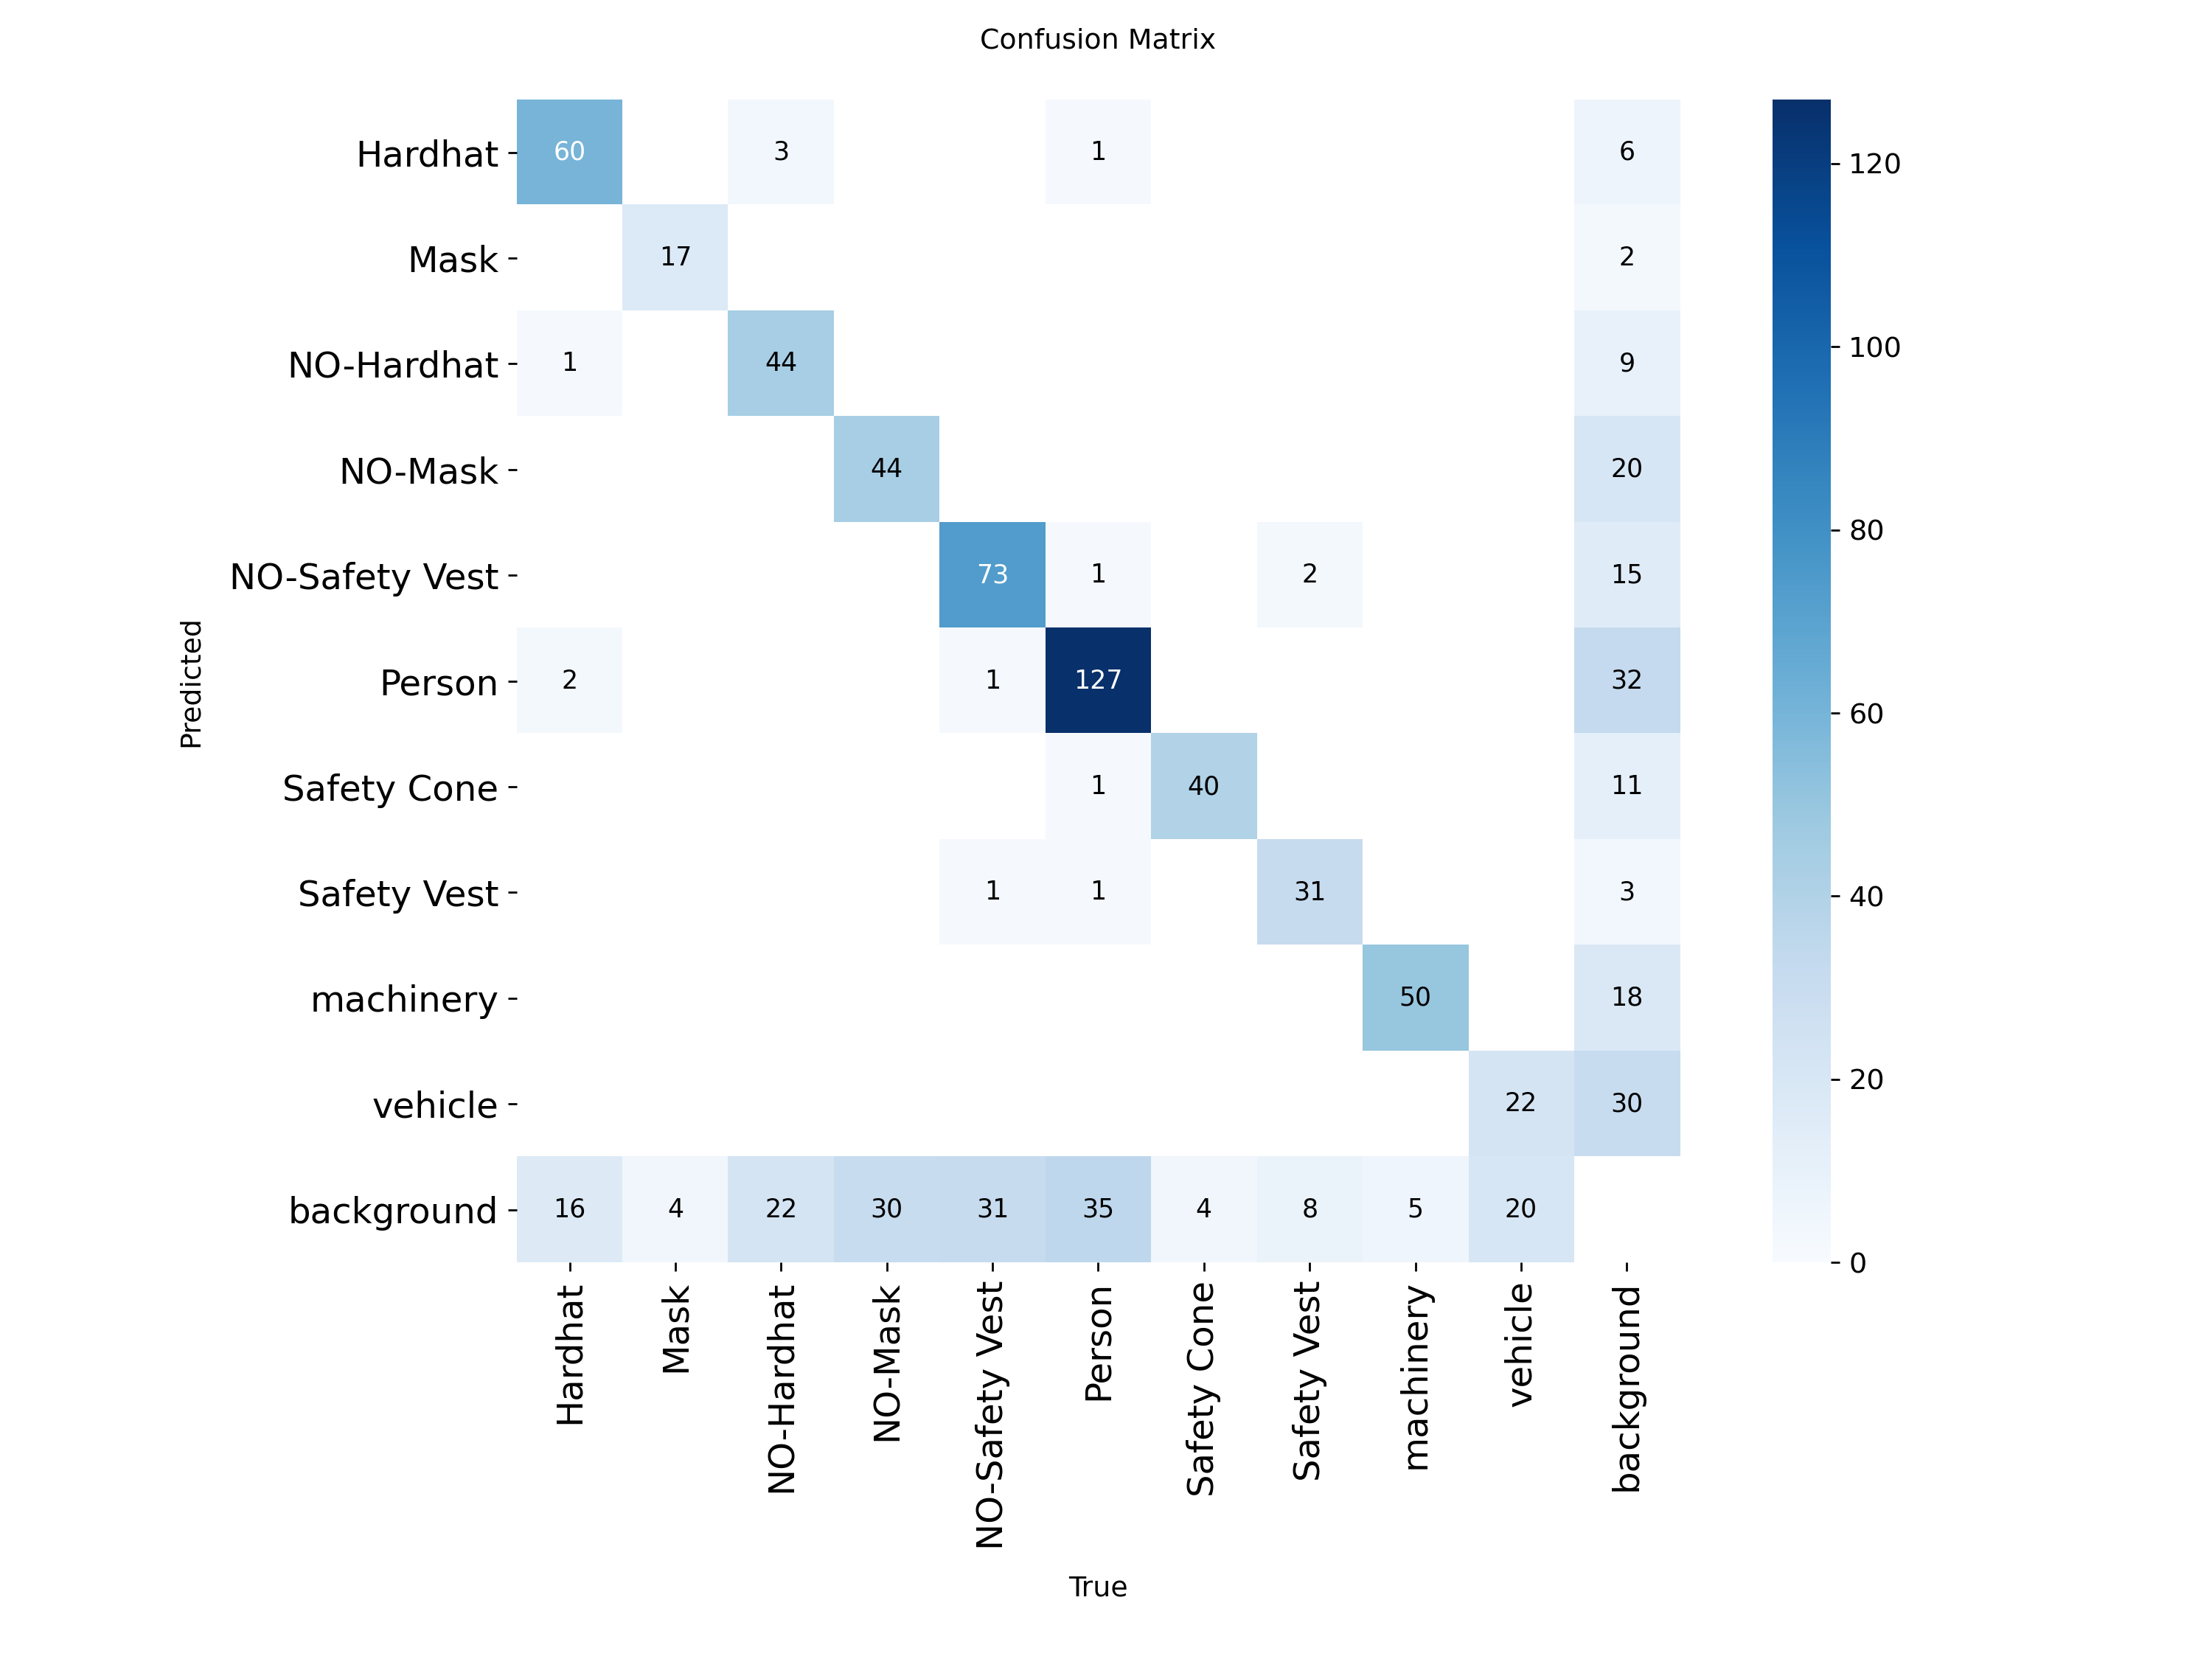

**confusion_matrix.png**  
`/content/runs/detect/val/confusion_matrix.png`

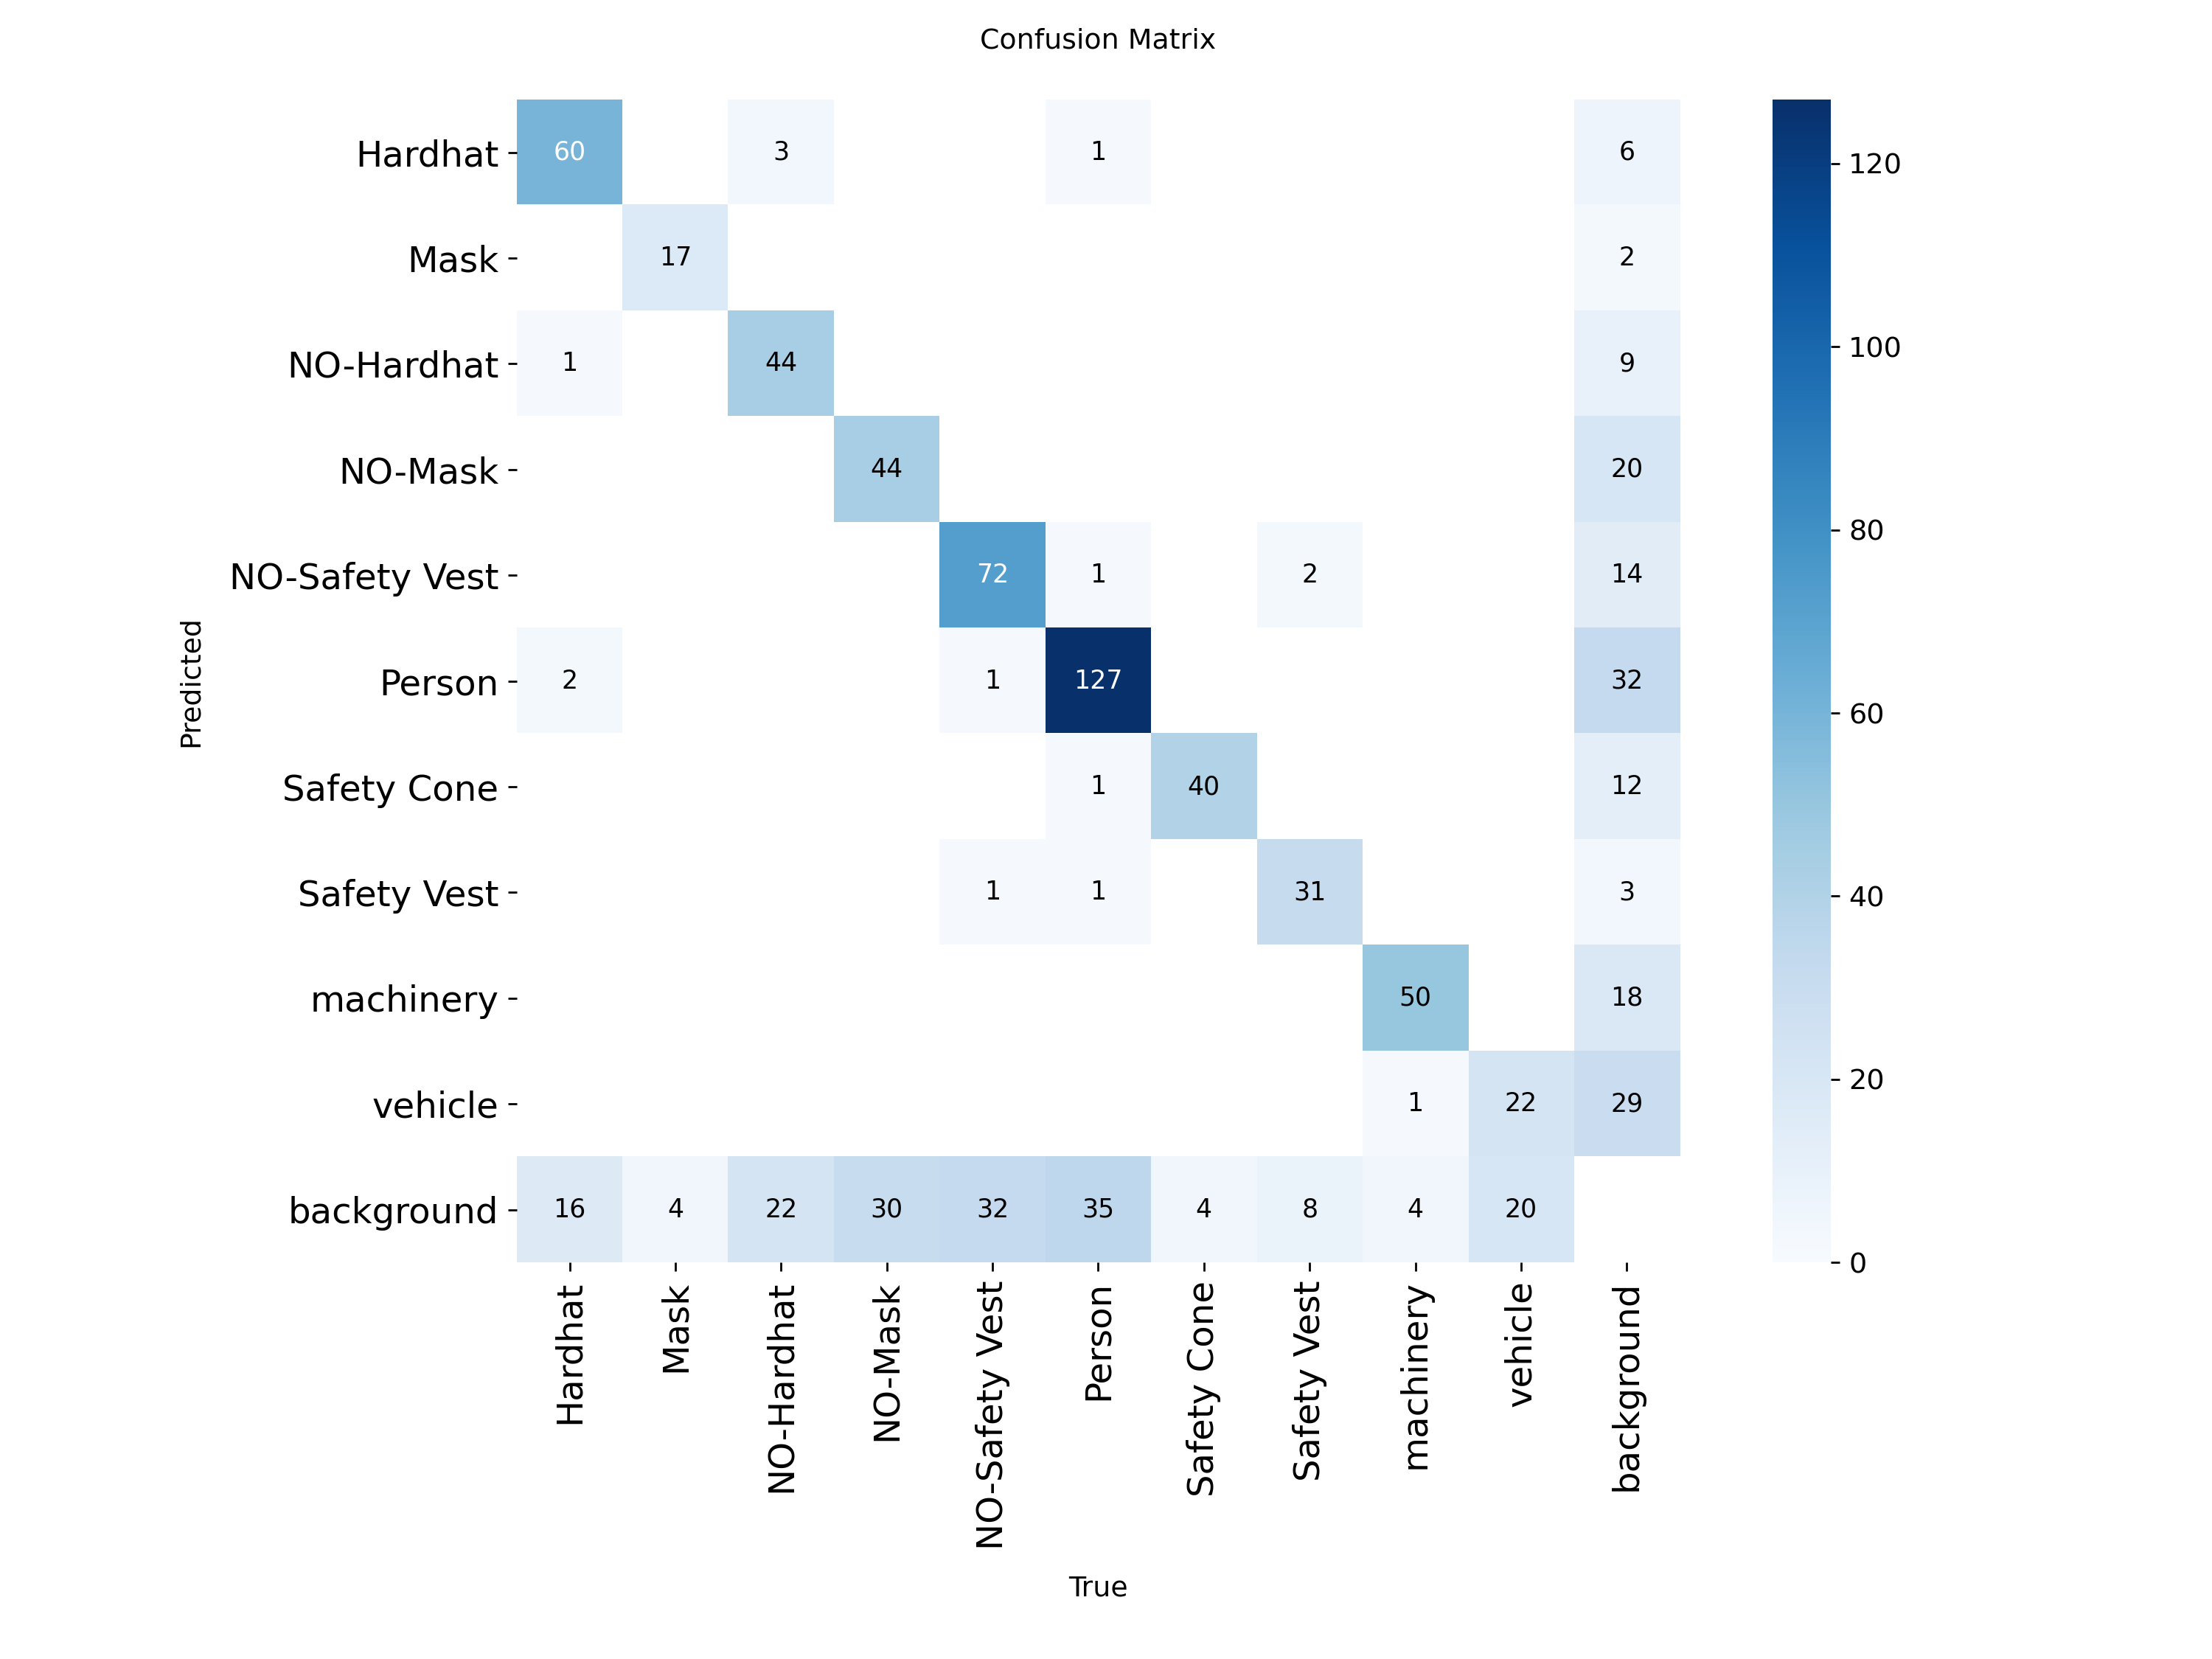

**confusion_matrix.png**  
`/content/runs/detect/val-2/confusion_matrix.png`

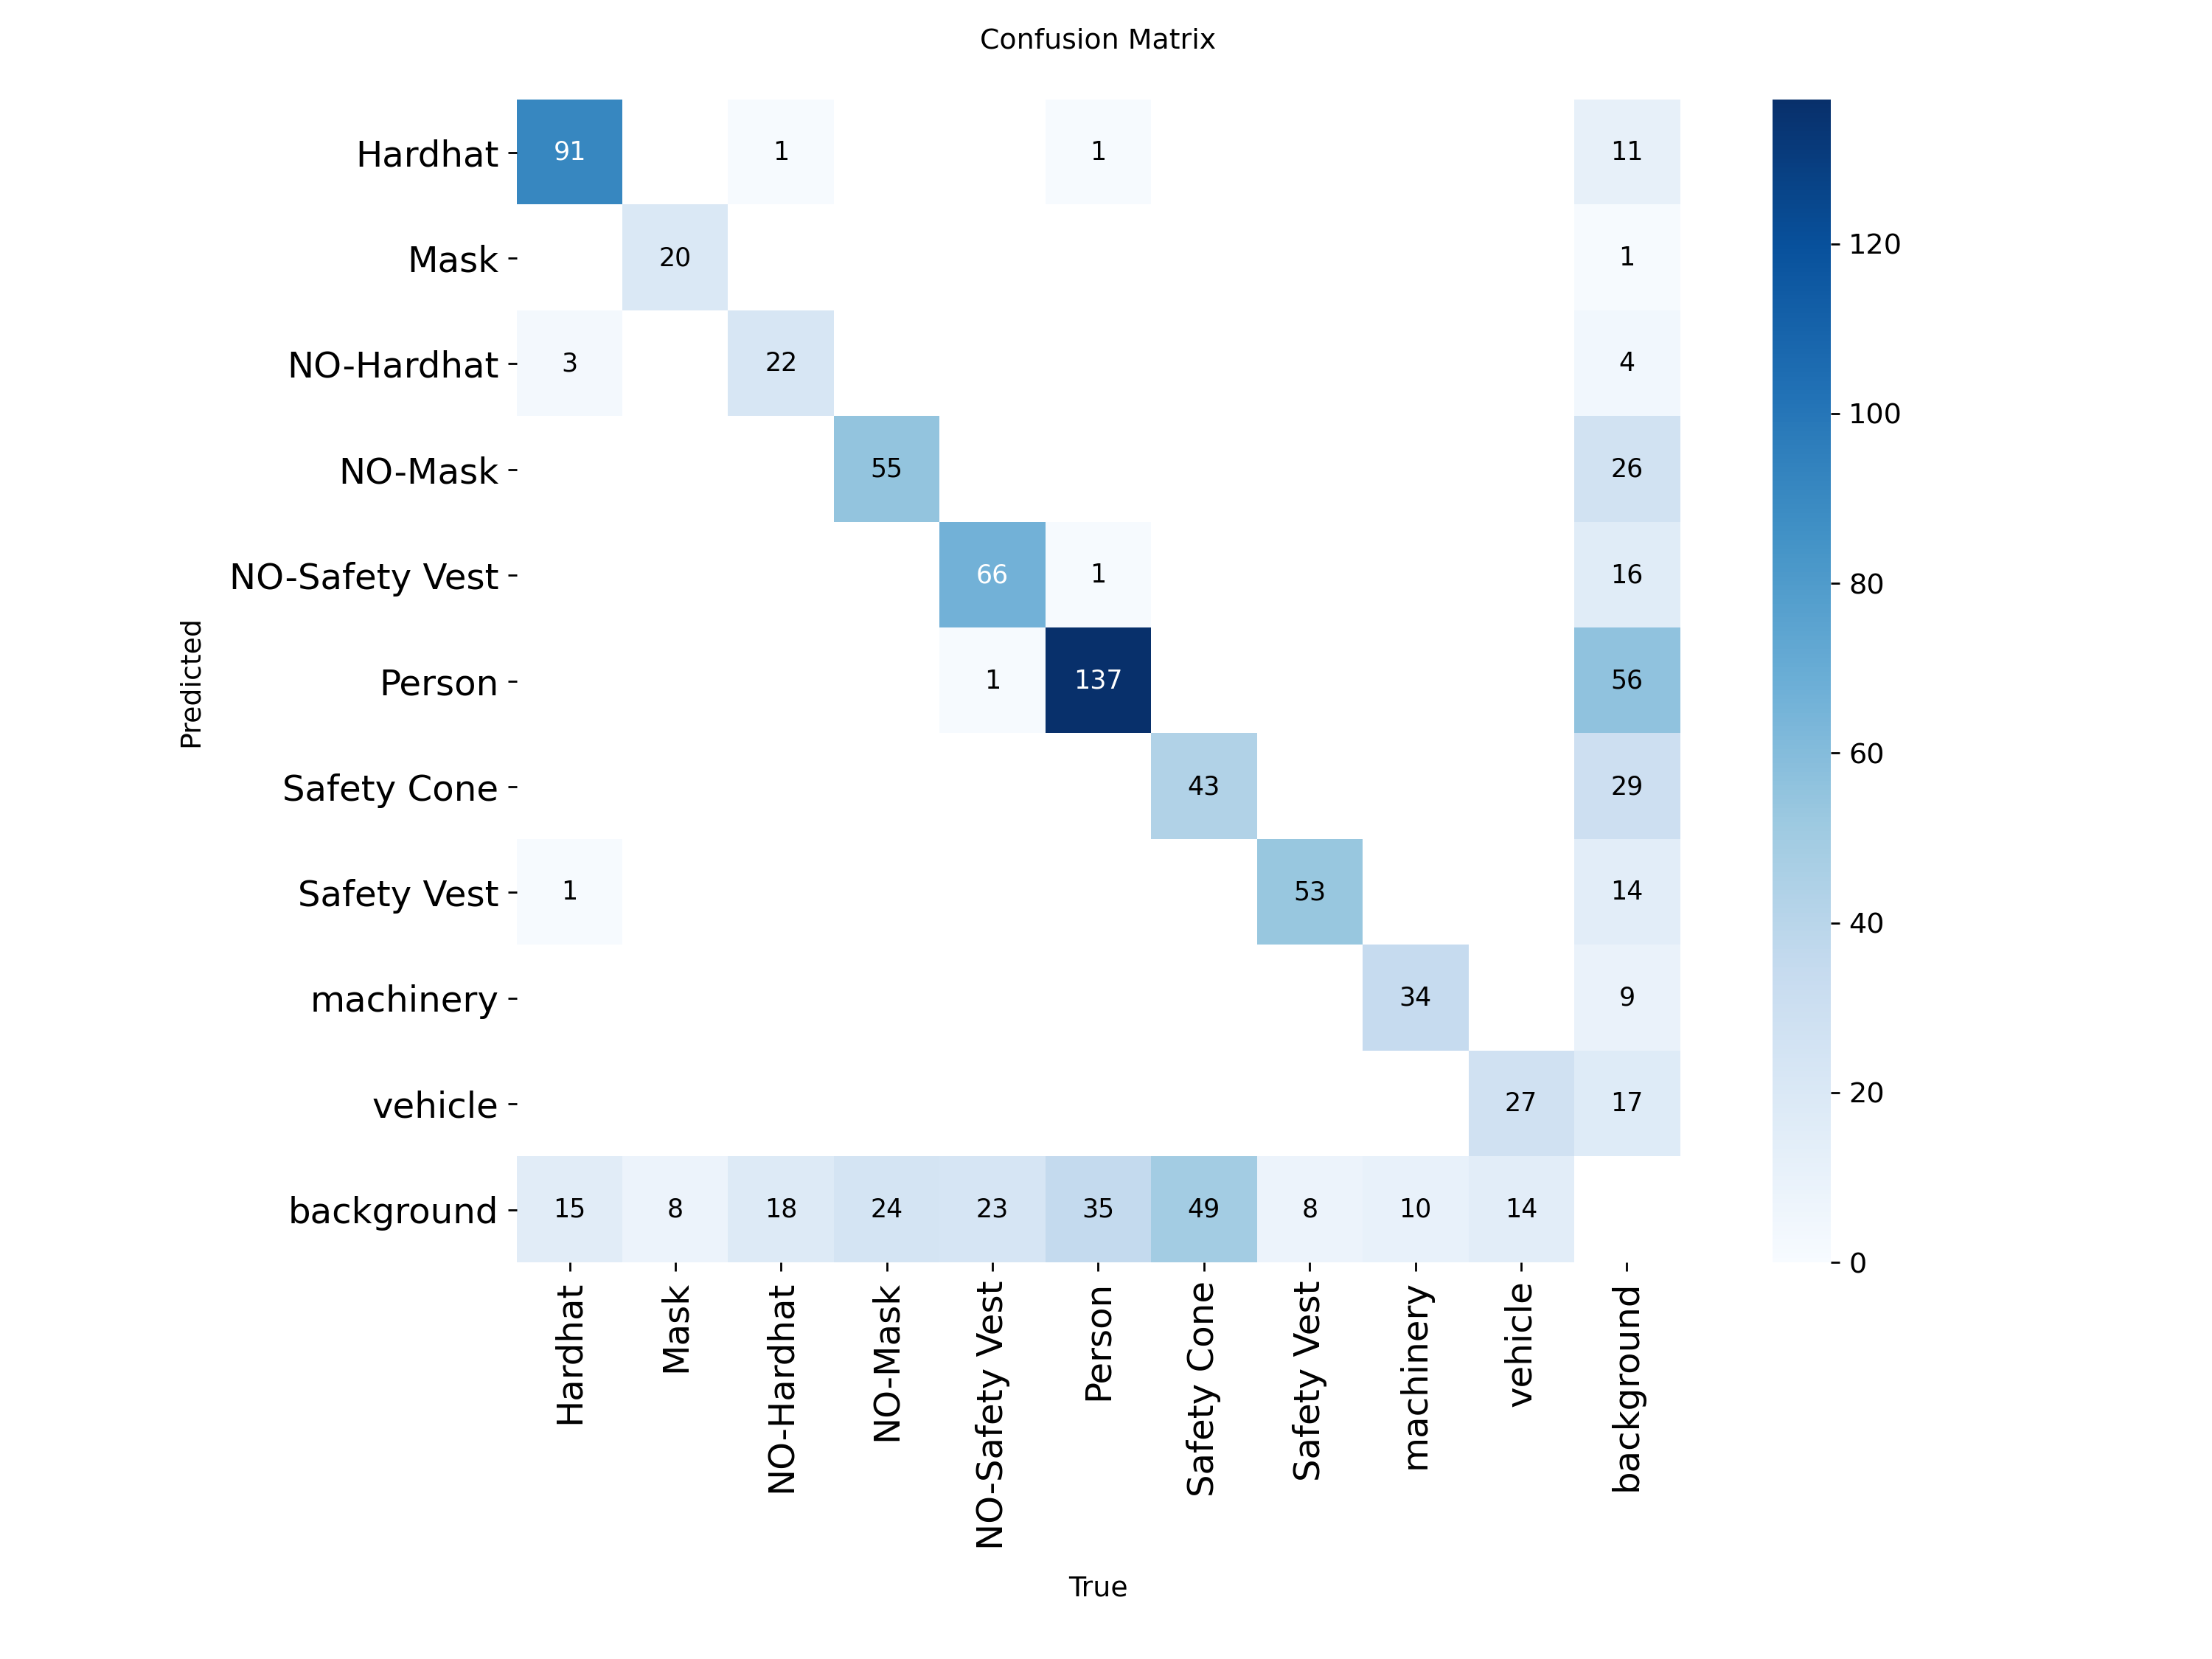

**results.png**  
`/content/drive/MyDrive/construction-safety-ppe/yolo_runs/ppe_yolov8n_baseline/results.png`

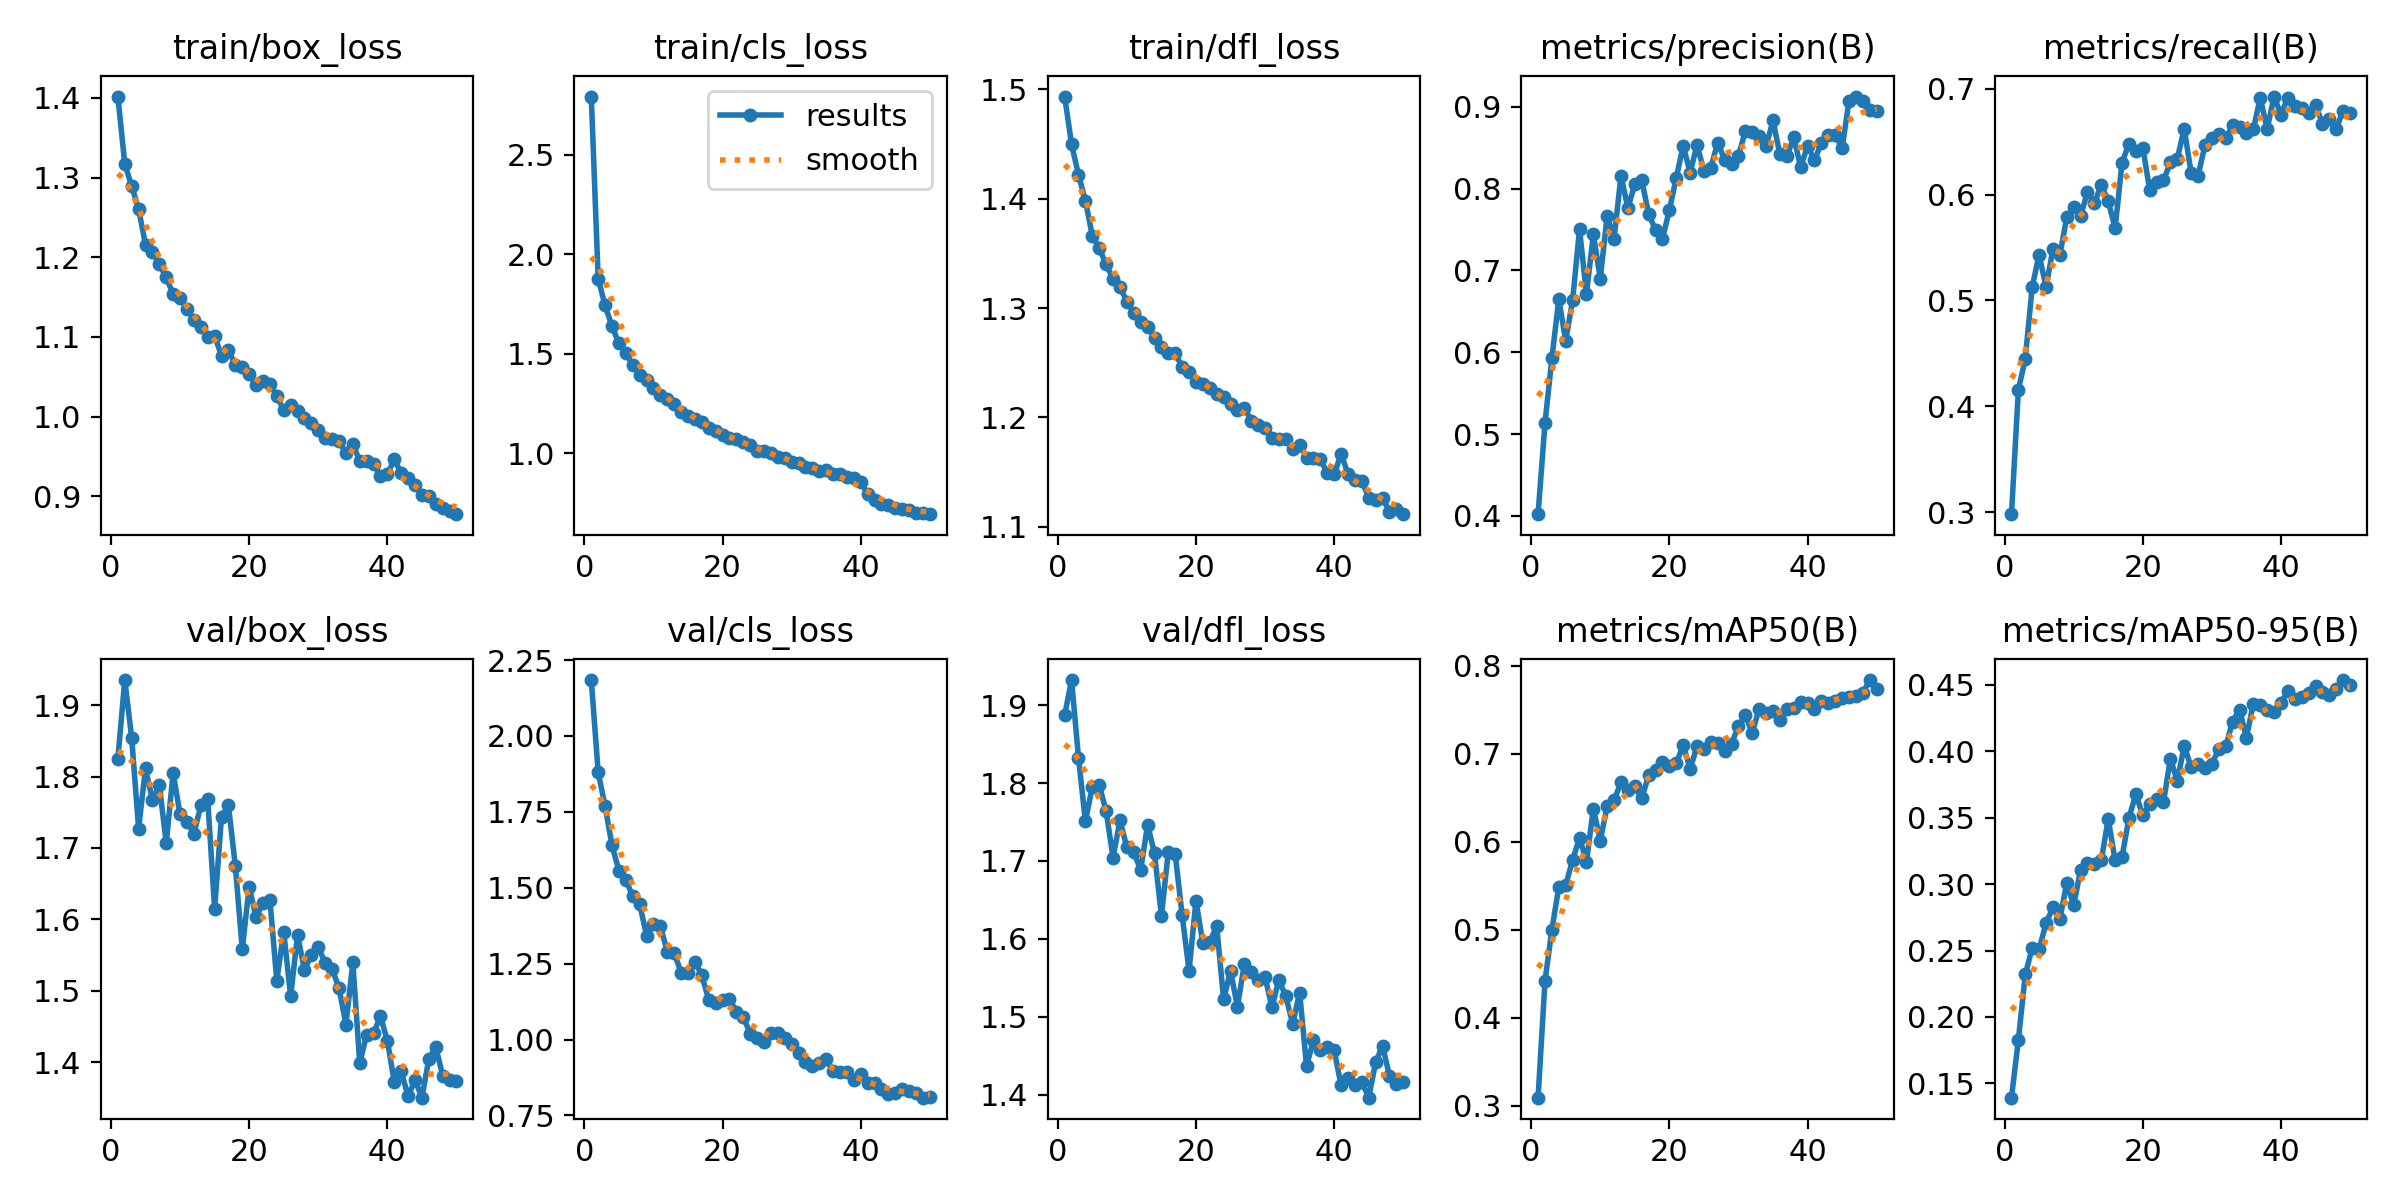

**confusion_matrix.png**  
`/content/drive/MyDrive/construction-safety-ppe/yolo_runs/ppe_yolov8n_baseline/confusion_matrix.png`

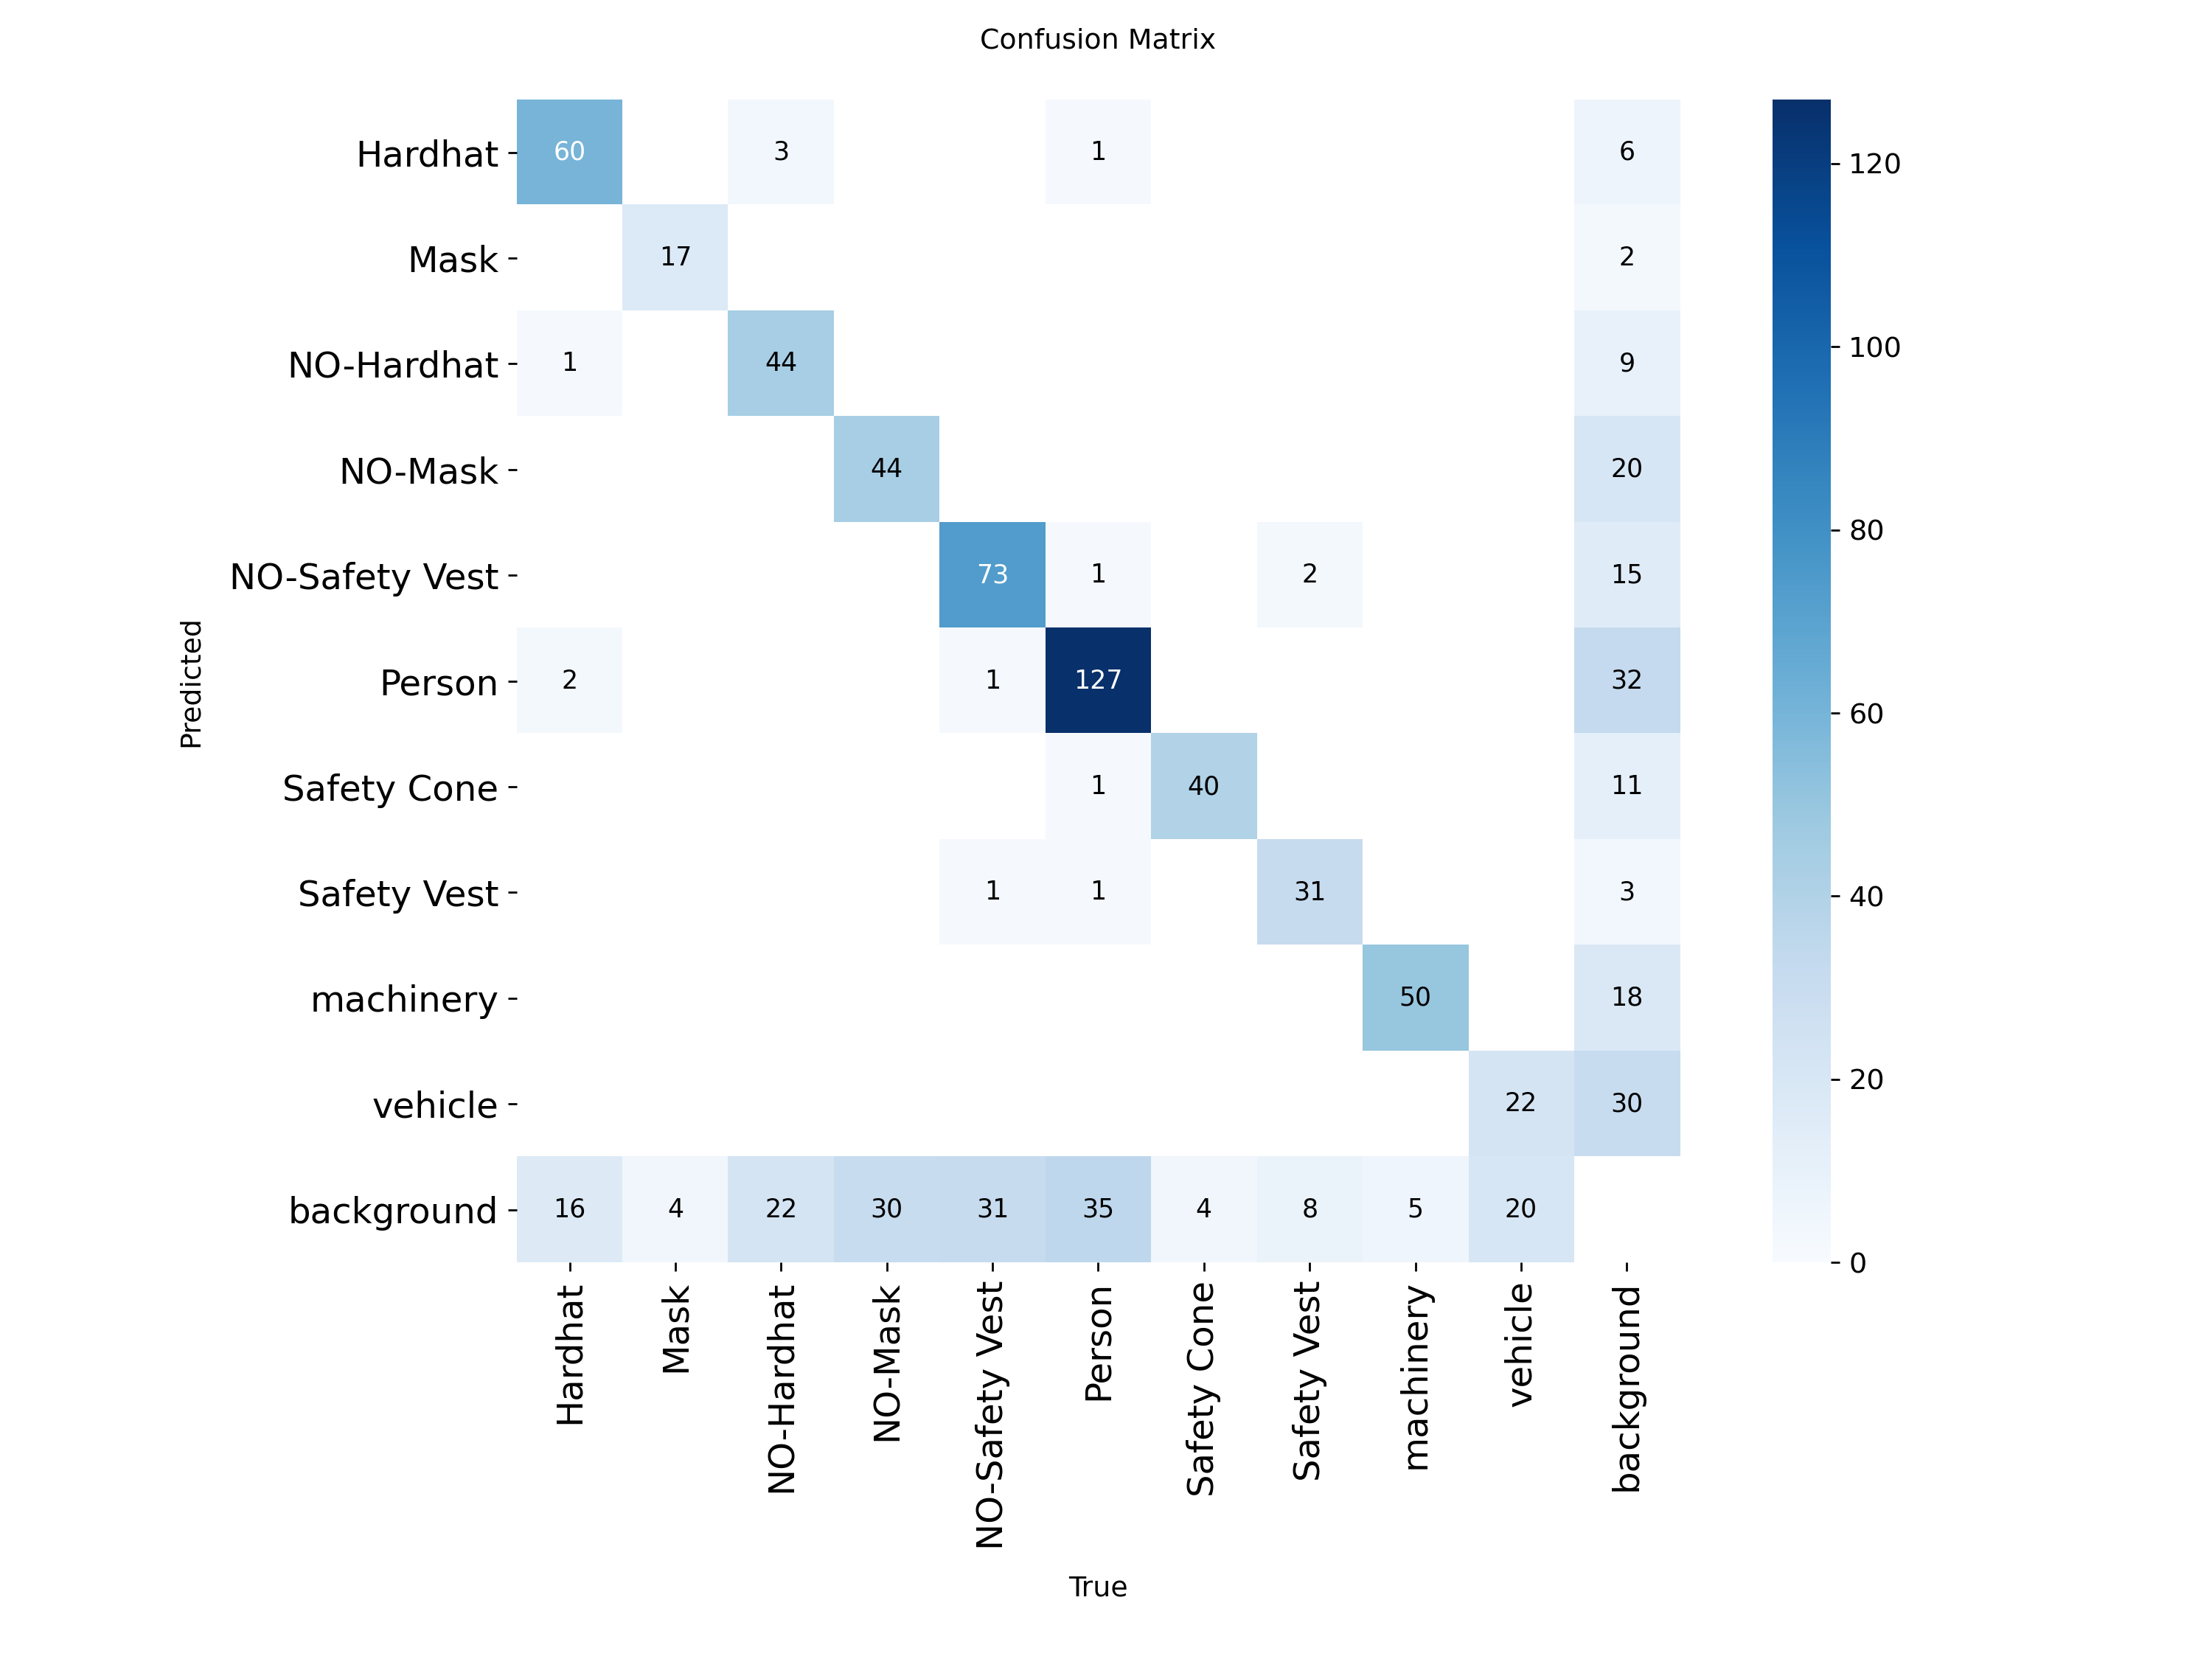

**IMG_0871_mp4-23_jpg.rf.03f872b1ed87ad7fadc85e09475ad37a.jpg**  
`/content/outputs/predictions/sample_compliance/IMG_0871_mp4-23_jpg.rf.03f872b1ed87ad7fadc85e09475ad37a.jpg`

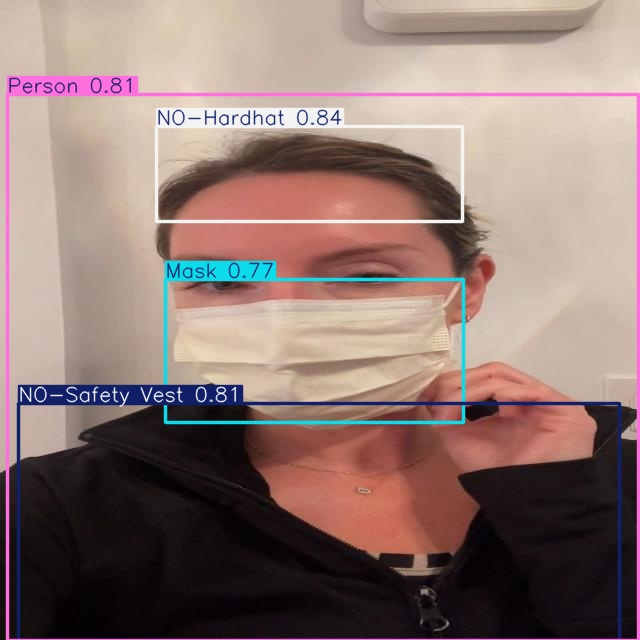

**youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg**  
`/content/drive/MyDrive/construction-safety-ppe/predictions/sample_compliance/youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg`

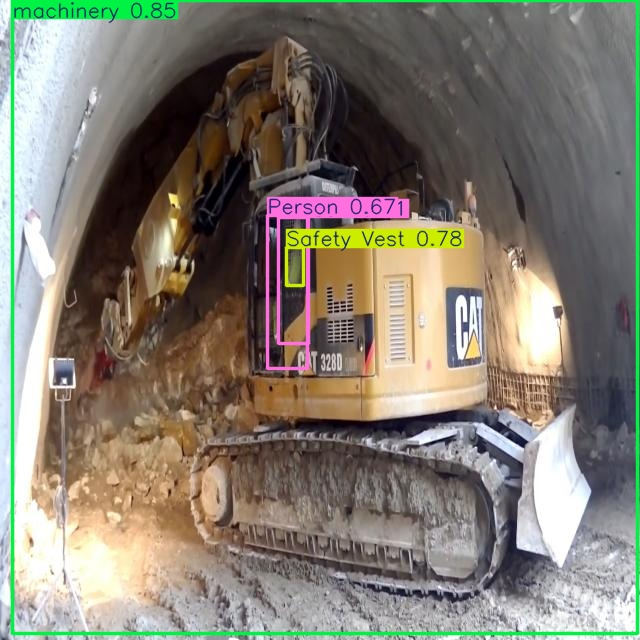

**val_batch0_pred.jpg**  
`/content/outputs/yolo_runs/ppe_yolov8n_baseline/val_batch0_pred.jpg`

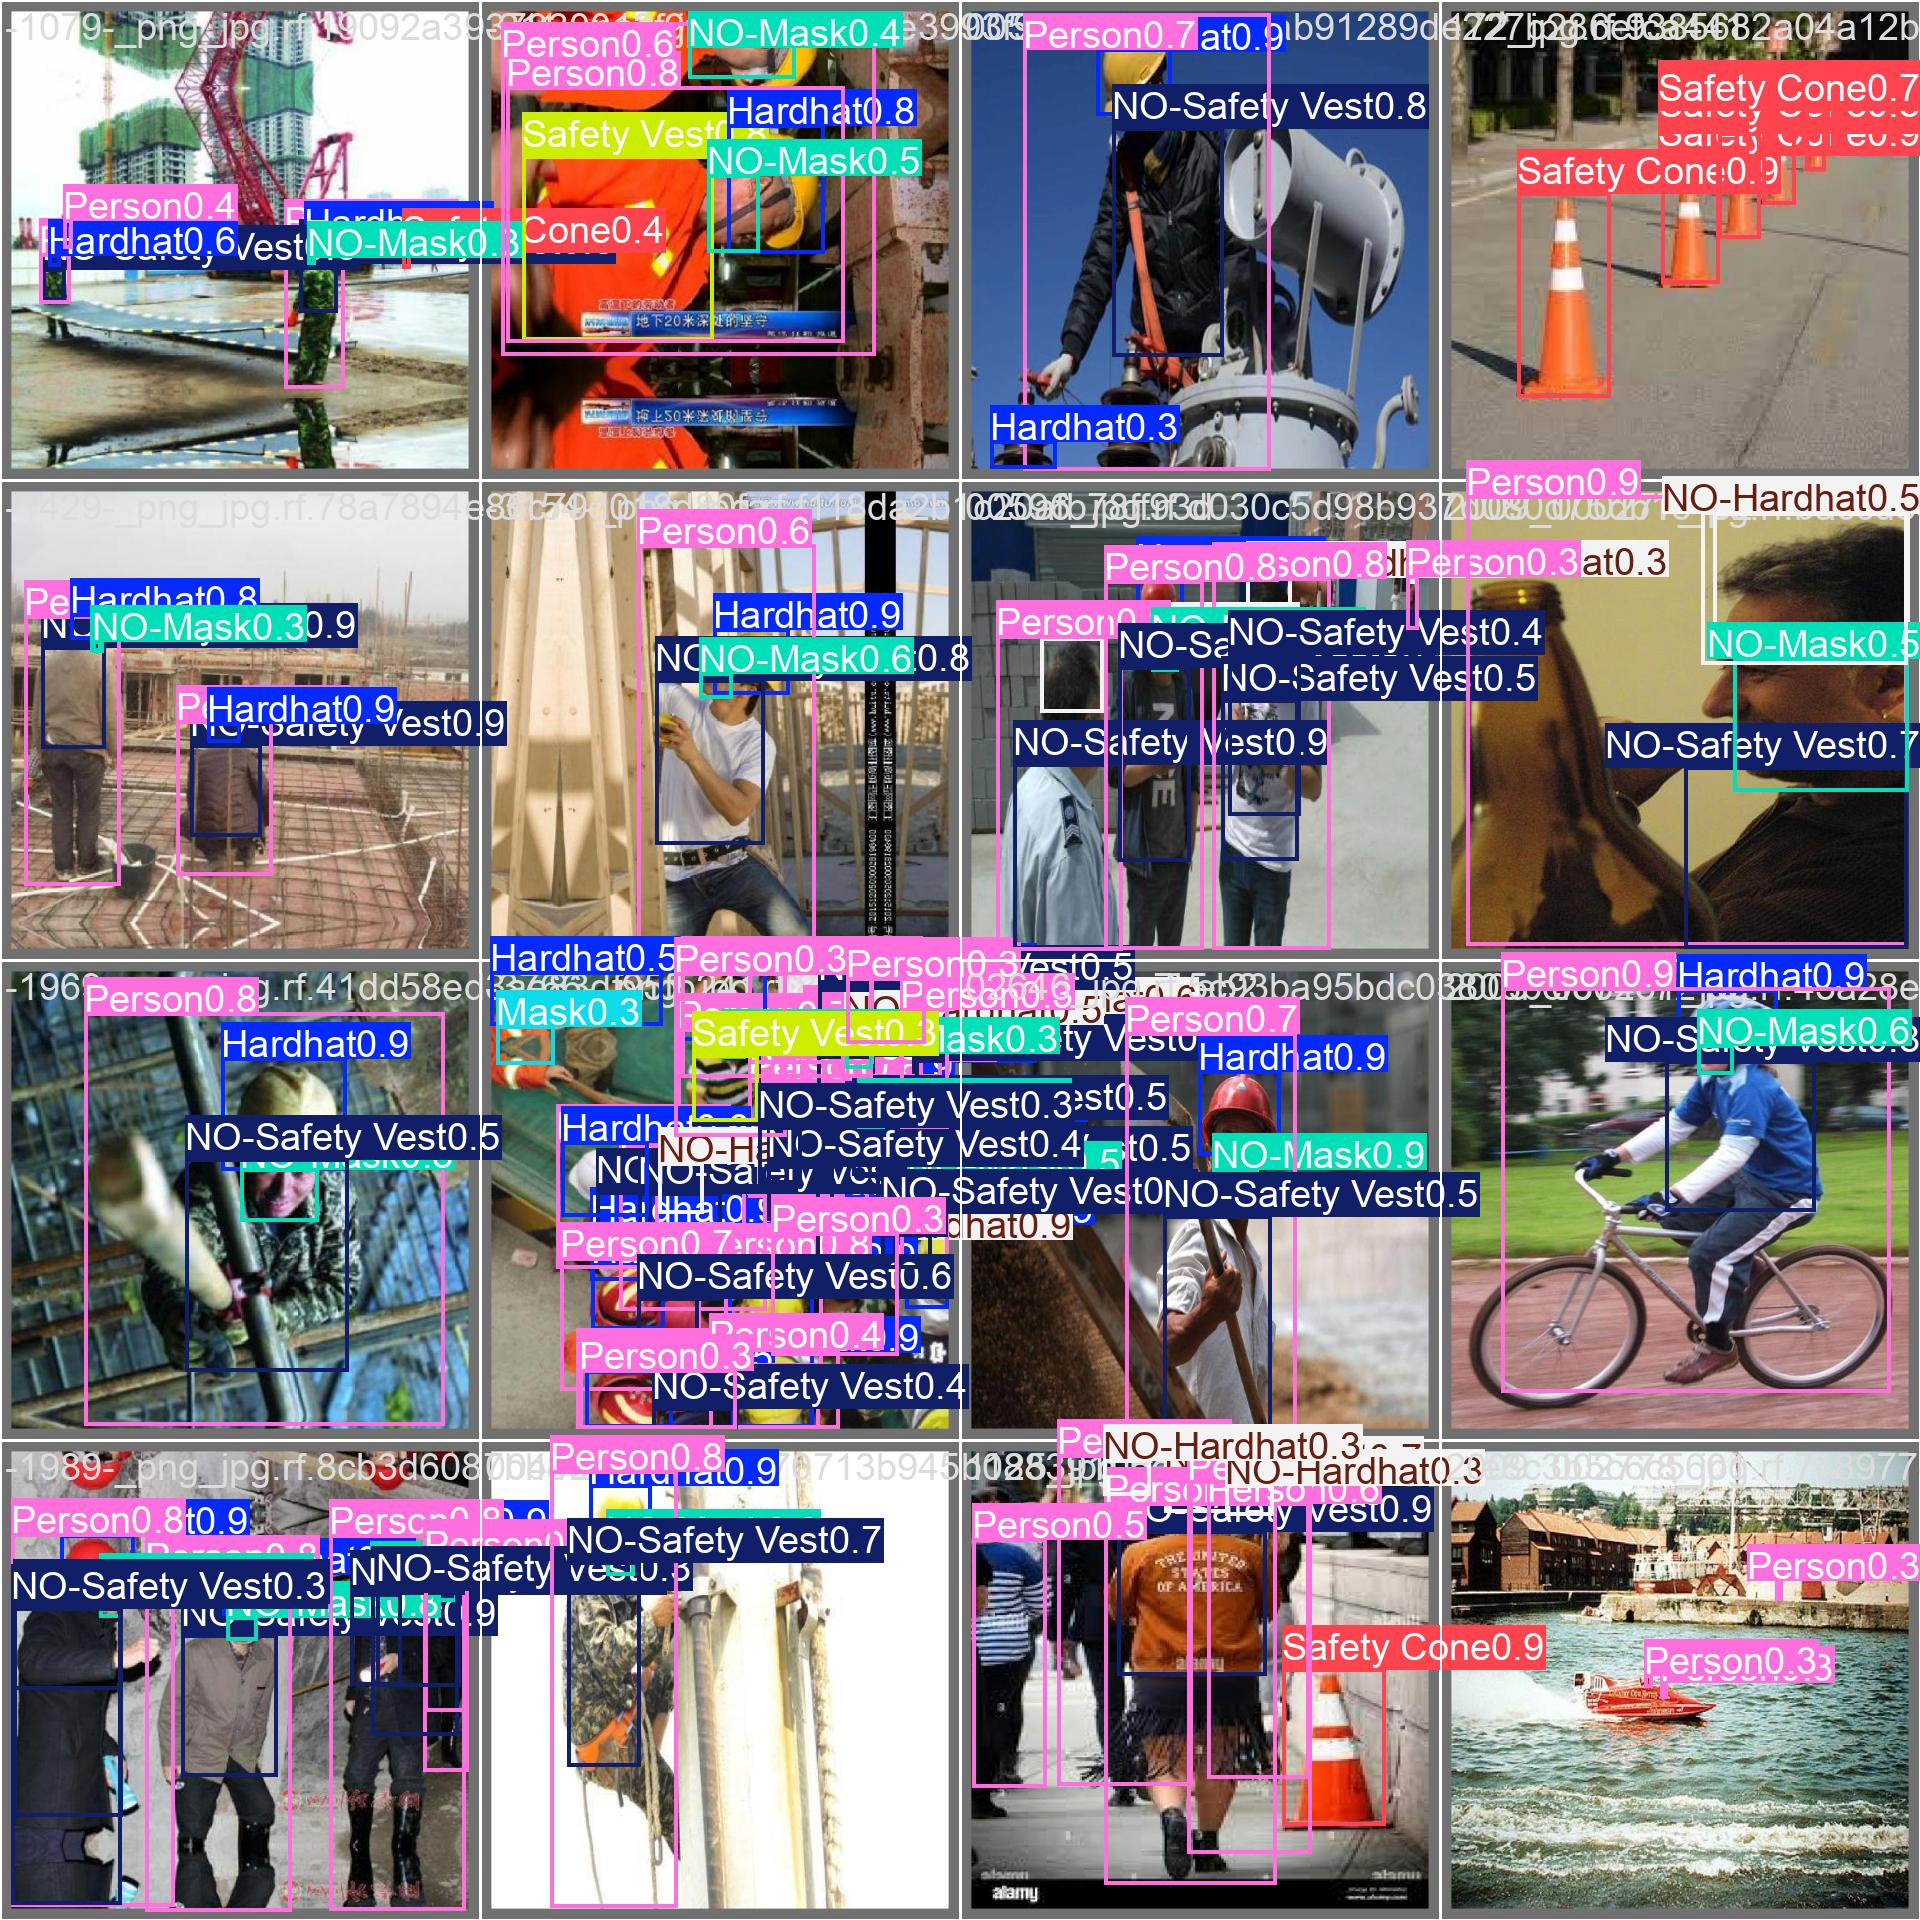

**val_batch1_pred.jpg**  
`/content/outputs/yolo_runs/ppe_yolov8n_baseline/val_batch1_pred.jpg`

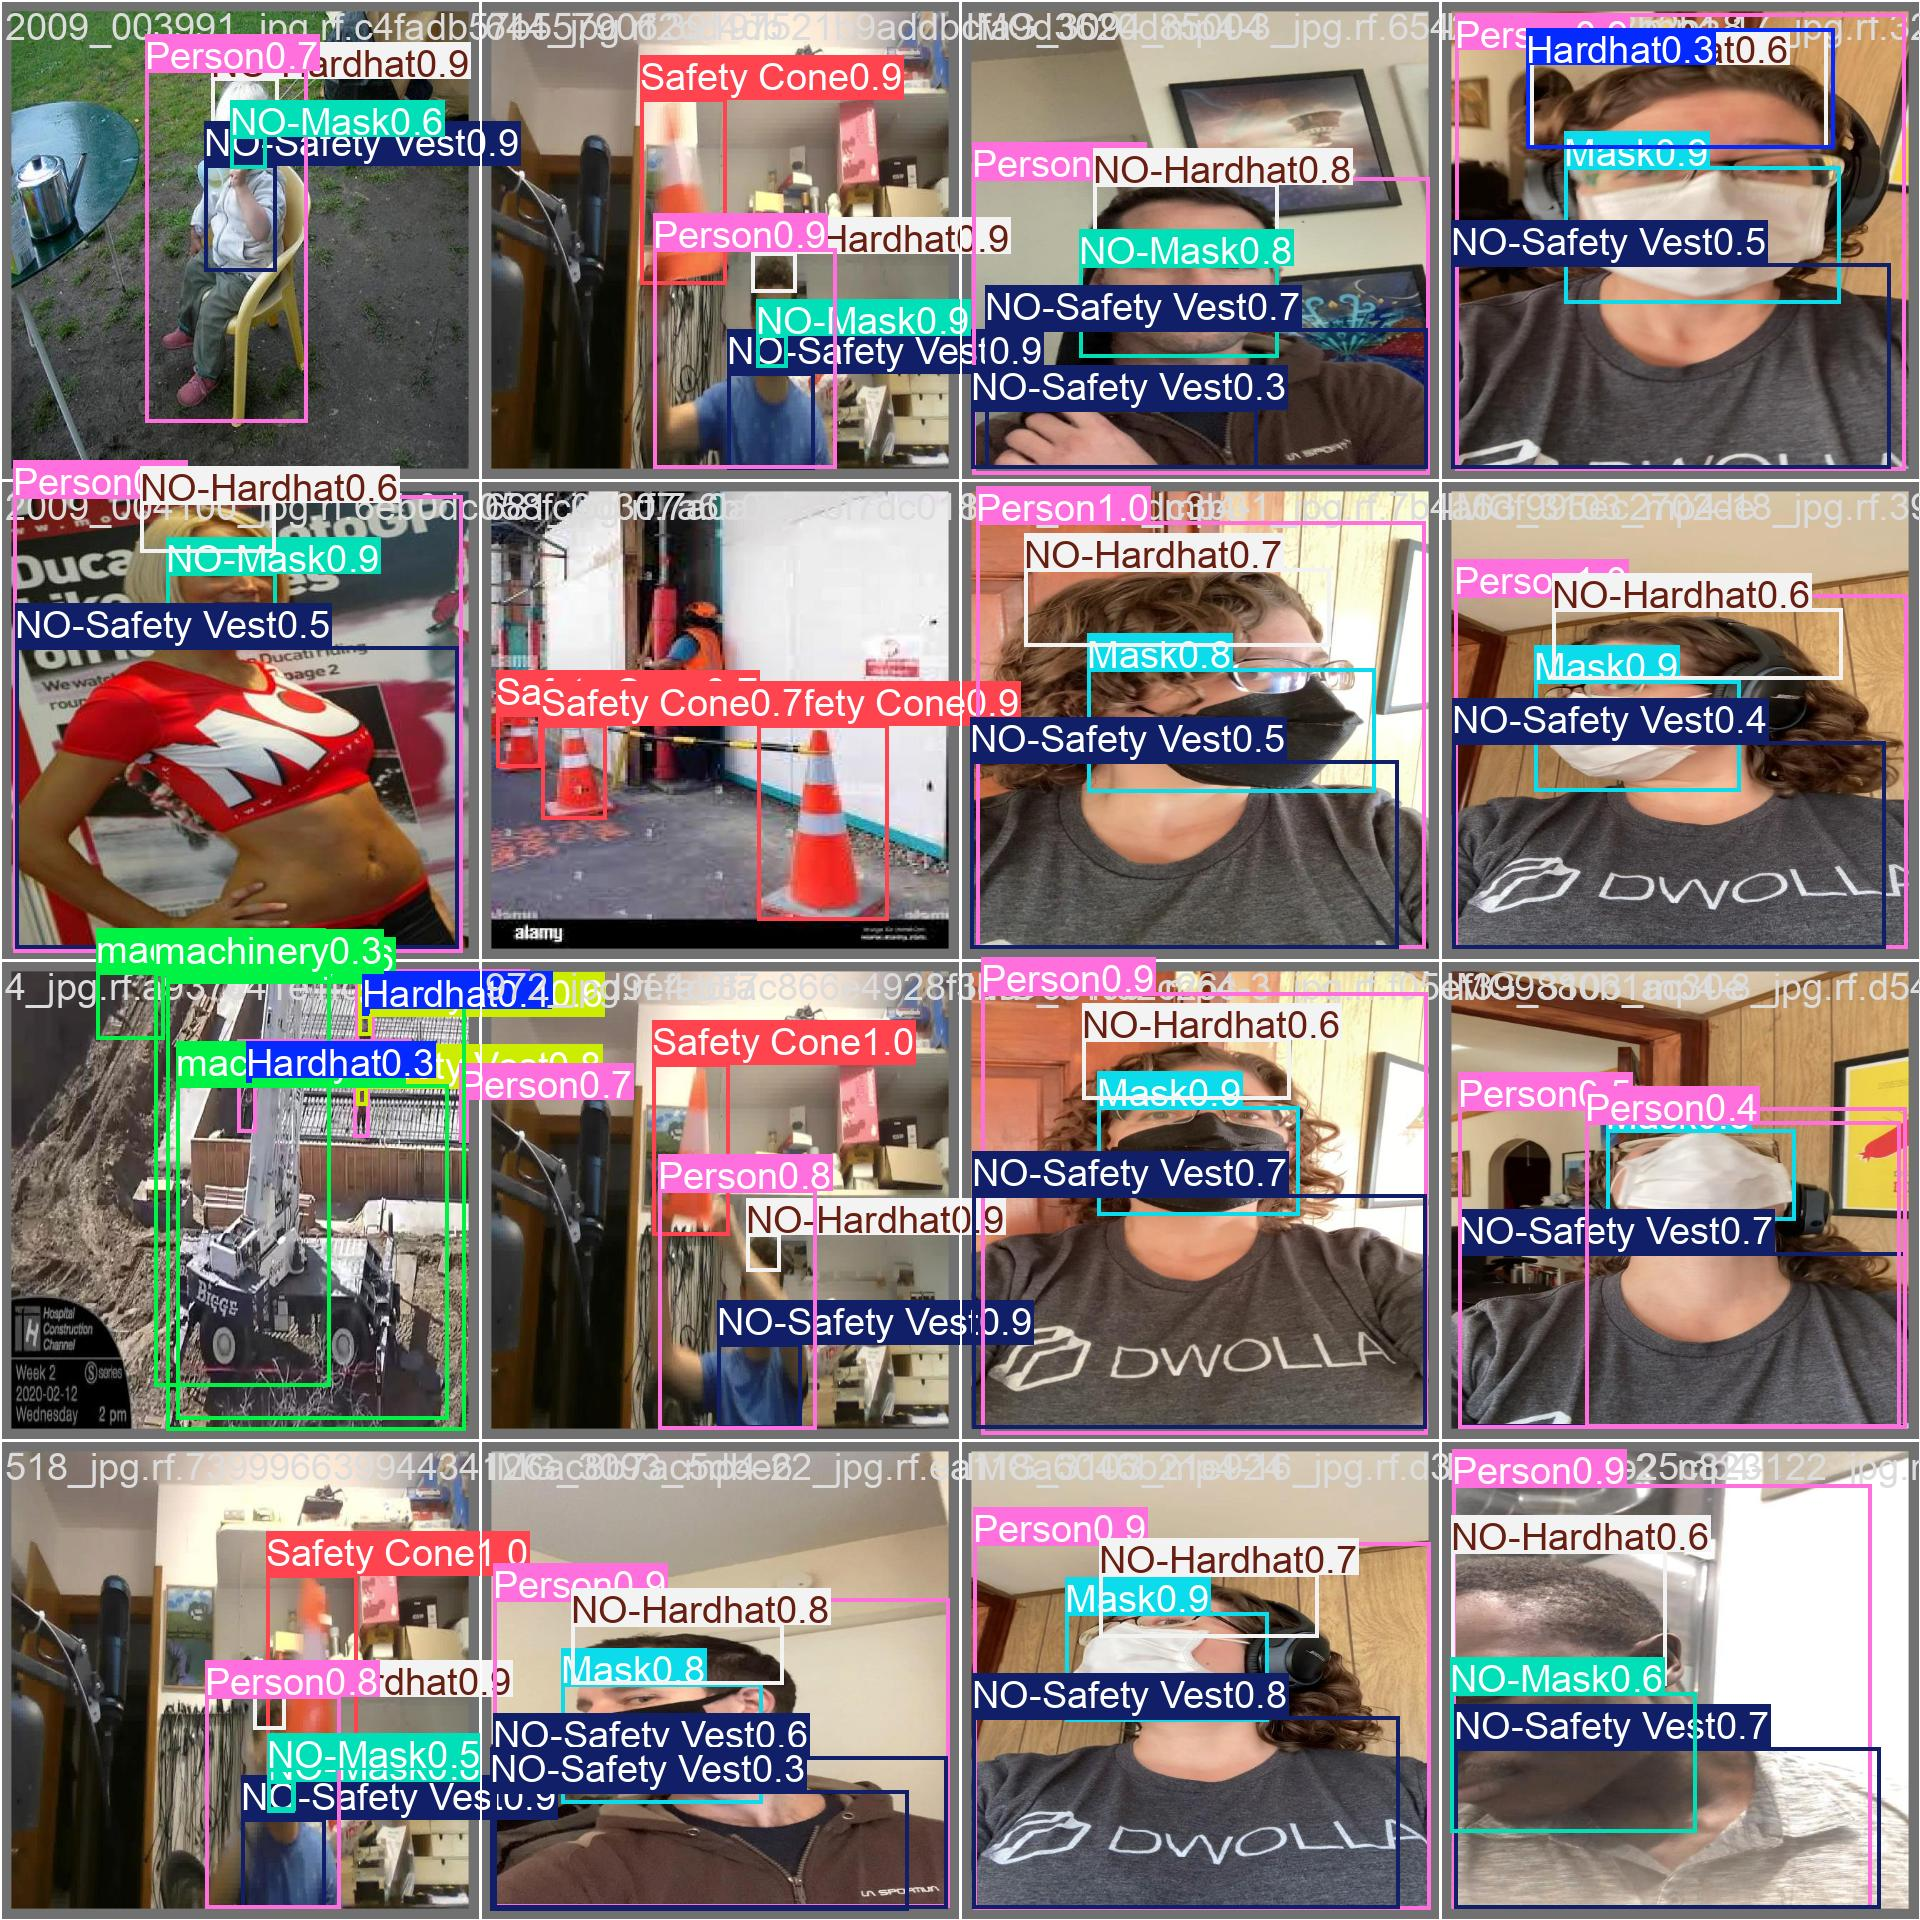

**val_batch2_pred.jpg**  
`/content/outputs/yolo_runs/ppe_yolov8n_baseline/val_batch2_pred.jpg`

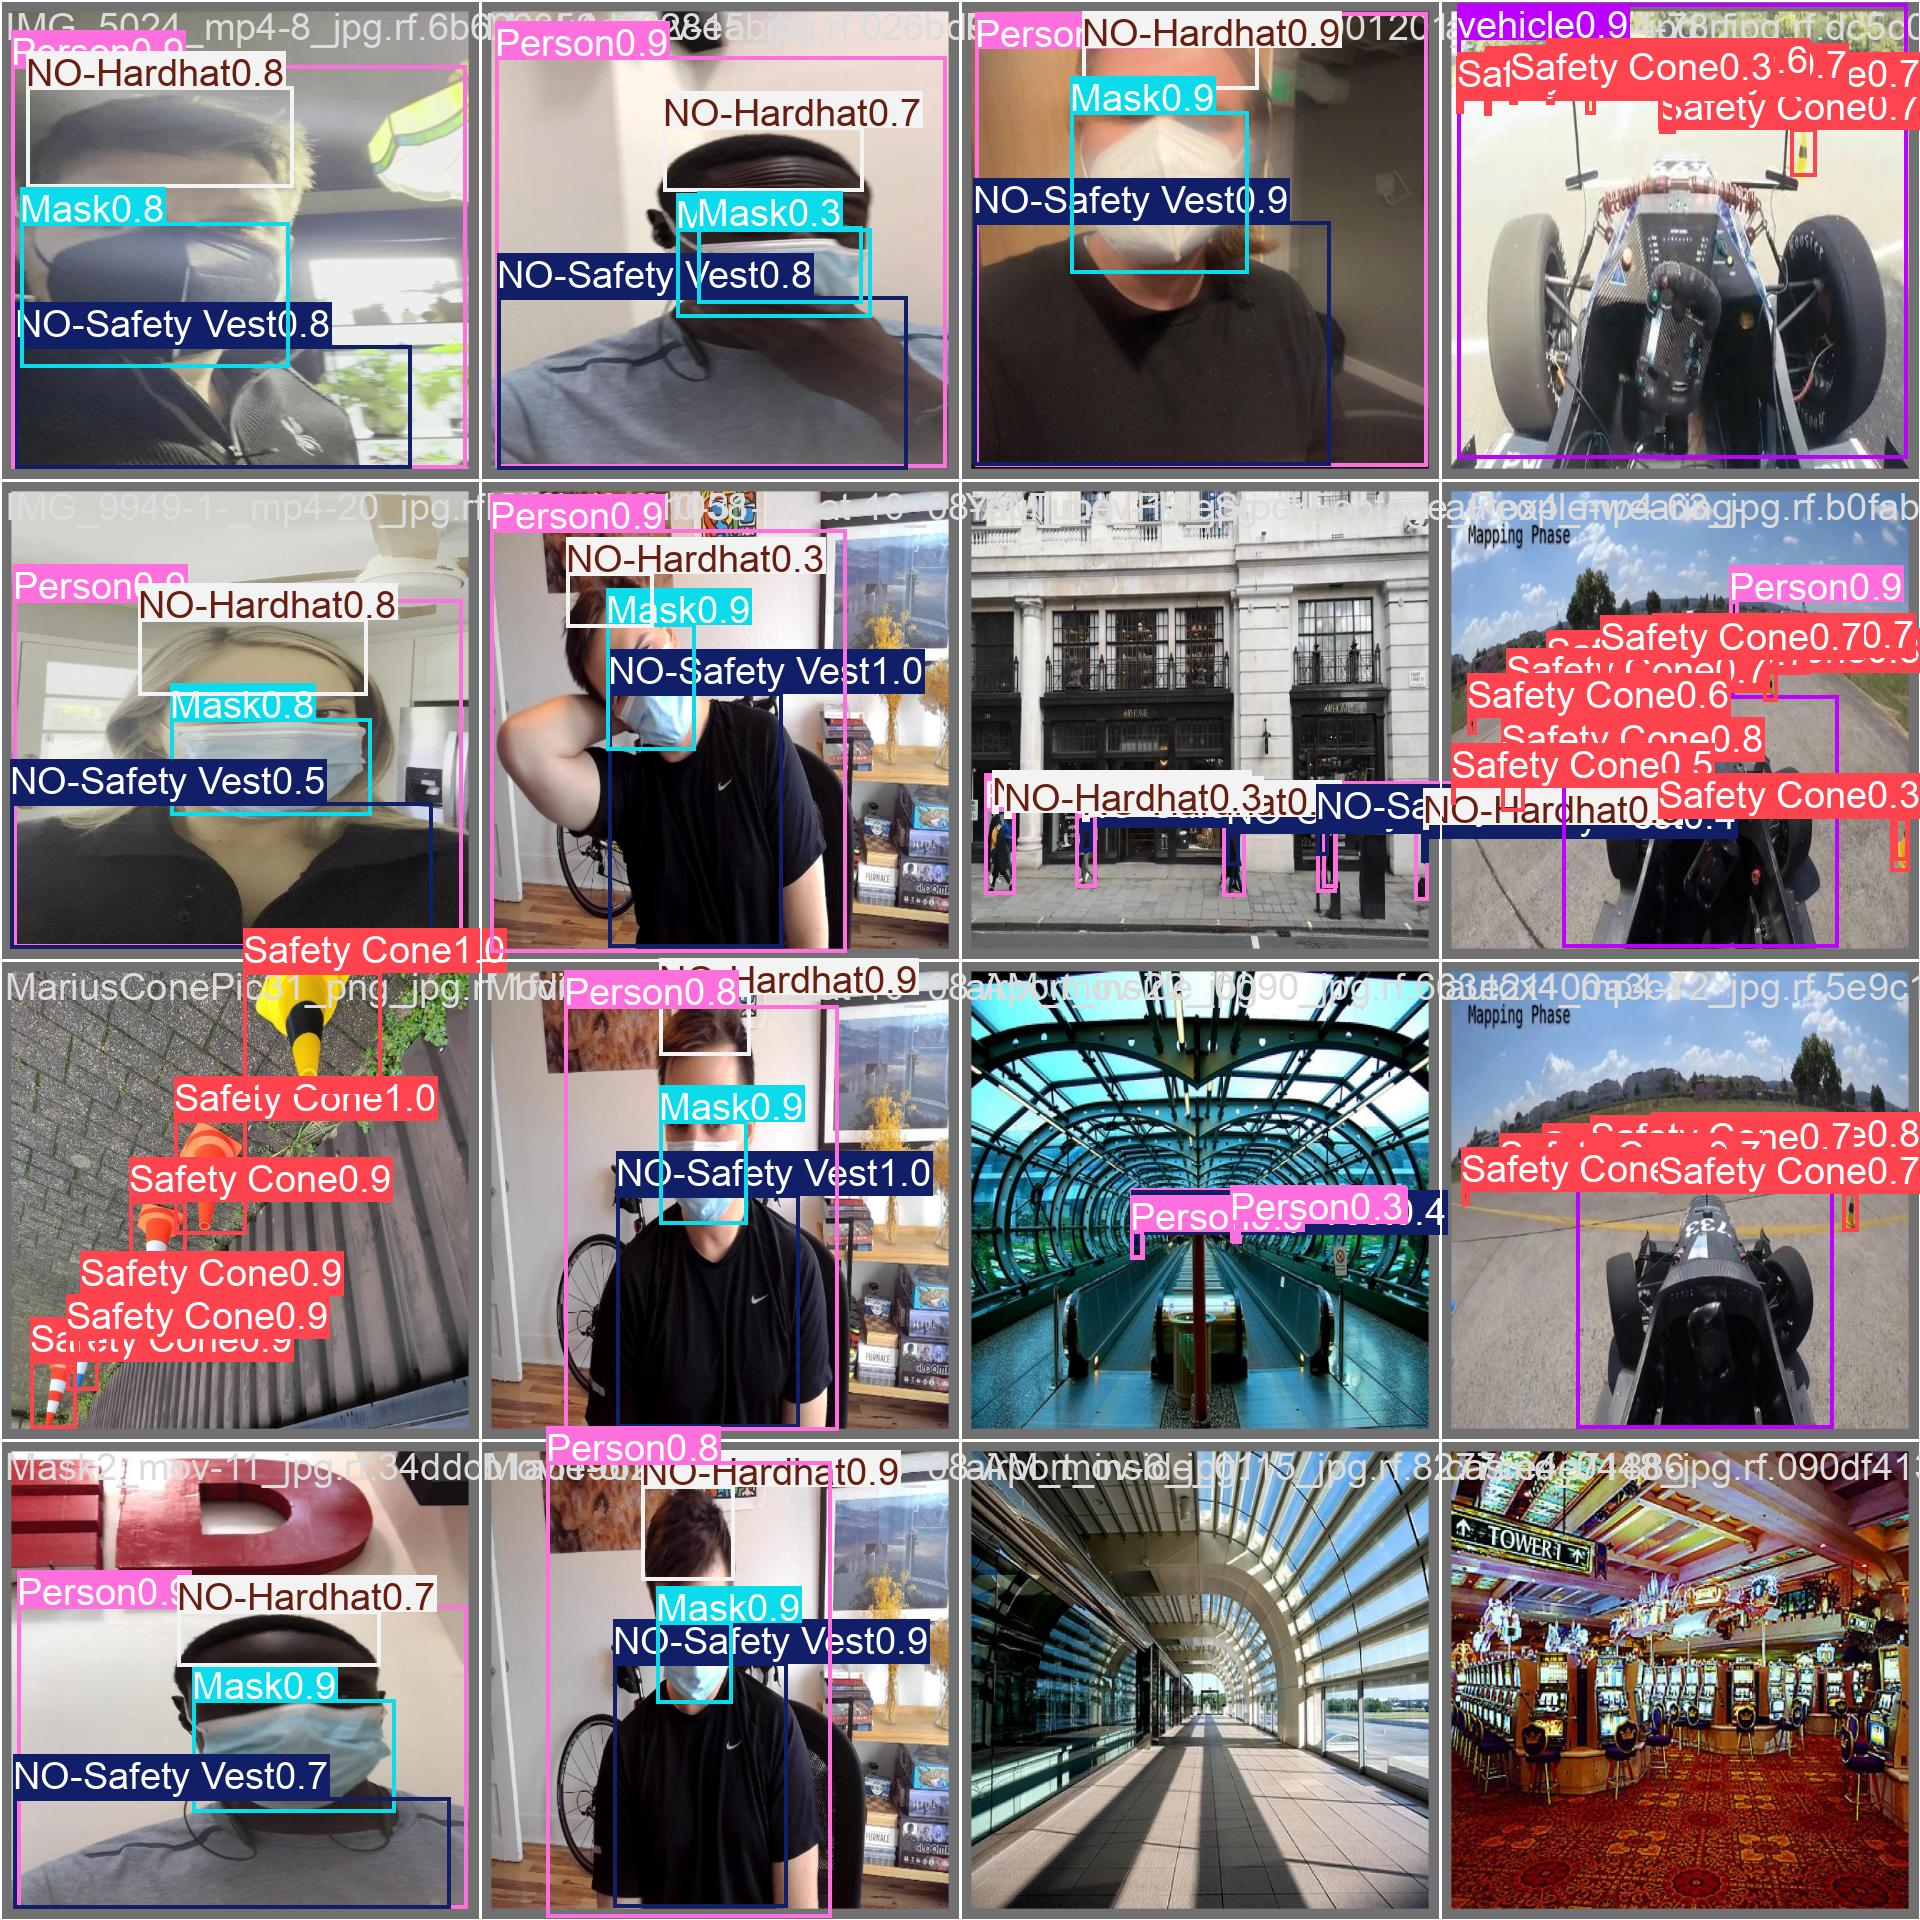

Se copiaron 55 imagenes adicionales, pero no se muestran para mantener el notebook legible.

In [18]:
from pathlib import Path
import shutil

from IPython.display import Image, Markdown, display

ARTIFACT_COPY_DIR = OUTPUT_BASE / "baseline_initial_artifacts"
ARTIFACT_COPY_DIR.mkdir(parents=True, exist_ok=True)

candidate_dirs = [
    Path("/content/outputs/yolo_runs/ppe_yolov8n_baseline"),
    Path("/content/outputs/predictions/sample_compliance"),
    Path("/content/runs/detect/val"),
    Path("/content/runs/detect/val-2"),
    OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline",
    OUTPUT_BASE / "predictions" / "sample_compliance",
]

summary_artifact_names = [
    "results.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
]
MAX_BATCH_EXAMPLES = 3
MAX_SAMPLE_PREDICTIONS = 2

all_images = []
summary_images = []
batch_prediction_images = []
sample_prediction_images = []

for directory in candidate_dirs:
    if not directory.exists():
        continue

    images = sorted(
        p for p in directory.rglob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )
    all_images.extend(images)

    for artifact_name in summary_artifact_names:
        artifact = directory / artifact_name
        if artifact.exists():
            summary_images.append(artifact)

    batch_prediction_images.extend(sorted(directory.glob("val_batch*_pred.jpg")))
    if directory.name == "sample_compliance":
        sample_prediction_images.extend(sorted(directory.glob("*.jpg")))

# Remove duplicates while preserving order.
def unique_paths(paths):
    unique = []
    seen = set()
    for image_path in paths:
        resolved = str(image_path.resolve())
        if resolved not in seen:
            unique.append(image_path)
            seen.add(resolved)
    return unique

all_images = unique_paths(all_images)
summary_images = unique_paths(summary_images)
batch_prediction_images = unique_paths(batch_prediction_images)[:MAX_BATCH_EXAMPLES]
sample_prediction_images = unique_paths(sample_prediction_images)[:MAX_SAMPLE_PREDICTIONS]
images_to_display = unique_paths(summary_images + sample_prediction_images + batch_prediction_images)

print(f"Imagenes encontradas en total: {len(all_images)}")
print(f"Imagenes mostradas en resumen: {len(images_to_display)}")

for image_path in all_images:
    relative_target = ARTIFACT_COPY_DIR / image_path.parent.name / image_path.name
    relative_target.parent.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copy2(image_path, relative_target)
    except shutil.SameFileError:
        pass

if not all_images:
    print("No encontre artefactos del baseline en las rutas esperadas.")
    print("Verifica que el runtime siga vivo y que exista /content/outputs/yolo_runs/ppe_yolov8n_baseline.")
else:
    display(Markdown(f"Artefactos completos copiados a `{ARTIFACT_COPY_DIR}`"))
    display(Markdown("### Resumen visual mostrado"))
    for image_path in images_to_display:
        display(Markdown(f"**{image_path.name}**  \n`{image_path}`"))
        display(Image(filename=str(image_path)))

    hidden_count = len(all_images) - len(images_to_display)
    if hidden_count > 0:
        display(Markdown(f"Se copiaron {hidden_count} imagenes adicionales, pero no se muestran para mantener el notebook legible."))


### Como leer los artefactos visuales del baseline

La celda anterior encontro 66 imagenes generadas por Ultralytics y mostro solo 11 para mantener el notebook legible. Estas son las piezas importantes y como interpretarlas:

- **`results.png`**: resume el entrenamiento por epoca. Las perdidas (`box_loss`, `cls_loss`, `dfl_loss`) deberian bajar o estabilizarse. Las metricas (`precision`, `recall`, `mAP50`, `mAP50-95`) deberian subir. En este baseline, el modelo aprendio de forma razonable, pero el recall quedo como el punto debil.

- **`confusion_matrix.png`**: muestra en que clases se confunde el detector. Es especialmente importante revisar las filas/columnas de `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`, porque esos errores afectan directamente la deteccion de incumplimientos.

- **`PR_curve.png`**: muestra la relacion entre precision y recall. Para una aplicacion de seguridad, no basta con precision alta; necesitamos recall alto en las clases `NO-*`, aunque eso pueda aumentar algunos falsos positivos.

- **`F1_curve.png`**: ayuda a elegir un umbral de confianza equilibrado. El umbral optimo para metricas generales puede no ser el mejor para seguridad. Por eso mas adelante usamos `COMPLIANCE_CONFIDENCE = 0.15`, buscando detectar mas posibles incumplimientos y mandar casos dudosos a revision.

- **`sample_compliance/*.jpg`**: son ejemplos individuales con cajas predichas. Sirven para validar que el sistema produce una salida entendible: persona detectada, EPP detectado e incumplimientos como `NO-Hardhat` o `NO-Safety Vest`.

- **`val_batch*_pred.jpg`**: muestran lotes de validacion con predicciones del modelo. Son utiles para detectar patrones de fallo: objetos pequenos, oclusiones, trabajadores parcialmente visibles, cascos/chalecos confundidos o cajas mal localizadas.

Lectura general del intento inicial: el modelo `yolov8n` ya sirve como baseline operativo porque entrega detecciones explicables, pero todavia necesita mejorar recall en incumplimientos. El siguiente experimento con `yolov8s` apunta justamente a reducir falsos negativos en las clases `NO-*`.

## 9. Experimento mejorado: YOLOv8s con persistencia en Drive

Este experimento usa un modelo mas grande que `yolov8n`. La meta no es solo subir accuracy global, sino mejorar deteccion de incumplimientos. En seguridad laboral conviene tolerar algunos falsos positivos si eso reduce falsos negativos peligrosos.

Recomendacion: ejecuta esta seccion en Colab con GPU. Los resultados se guardan en `OUTPUT_BASE`, que ahora apunta a Google Drive cuando `USE_GOOGLE_DRIVE = True`.

In [19]:
IMPROVED_MODEL_WEIGHTS = "yolov8s.pt"
IMPROVED_RUN_NAME = "ppe_yolov8s_recall_focus"
IMPROVED_EPOCHS = 75
IMPROVED_BATCH_SIZE = 16 if torch.cuda.is_available() else 4
RUN_IMPROVED_TRAINING = False

if RUN_IMPROVED_TRAINING:
    improved_model = YOLO(IMPROVED_MODEL_WEIGHTS)
    improved_train_results = improved_model.train(
        data=str(DATA_YAML_PATH),
        epochs=IMPROVED_EPOCHS,
        imgsz=IMG_SIZE,
        batch=IMPROVED_BATCH_SIZE,
        device=DEVICE,
        project=str((OUTPUT_BASE / "yolo_runs").resolve()),
        name=IMPROVED_RUN_NAME,
        exist_ok=True,
        patience=20,
        seed=42,
        cache=True,
        plots=True,
        cos_lr=True,
        close_mosaic=10,
    )
else:
    print("RUN_IMPROVED_TRAINING=False. Cambialo a True para entrenar el modelo mejorado.")

RUN_IMPROVED_TRAINING=False. Cambialo a True para entrenar el modelo mejorado.


In [20]:
RUN_IMPROVED_EVALUATION = True

if RUN_IMPROVED_EVALUATION:
    improved_model_path = OUTPUT_BASE / "yolo_runs" / IMPROVED_RUN_NAME / "weights" / "best.pt"
    if not improved_model_path.exists():
        raise FileNotFoundError(
            f"No existe {improved_model_path}. Ejecuta primero el entrenamiento mejorado."
        )

    improved_eval_model = YOLO(str(improved_model_path))

    print("Validacion modelo mejorado:")
    improved_val_metrics = improved_eval_model.val(
        data=str(DATA_YAML_PATH),
        split="val",
        imgsz=IMG_SIZE,
        device=DEVICE,
        project=str((OUTPUT_BASE / "yolo_eval").resolve()),
        name=f"{IMPROVED_RUN_NAME}_val",
        exist_ok=True,
    )

    print("Test modelo mejorado:")
    improved_test_metrics = improved_eval_model.val(
        data=str(DATA_YAML_PATH),
        split="test",
        imgsz=IMG_SIZE,
        device=DEVICE,
        project=str((OUTPUT_BASE / "yolo_eval").resolve()),
        name=f"{IMPROVED_RUN_NAME}_test",
        exist_ok=True,
    )
else:
    print("RUN_IMPROVED_EVALUATION=False. Cambialo a True para evaluar el modelo mejorado.")

Validacion modelo mejorado:
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 82.6±26.7 MB/s, size: 48.3 KB)
val: Scanning /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid/labels... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 431.5it/s 0.3ss
WARNING ⚠️ val: Cache directory /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4it/s 5.6s0.3ss
                   all        114        697      0.906      0.779      0.849      0.566
               Hardhat         42         79      0.915      0.814      0.895      0.618
                  Mask         19         21      0.971      0.905      0.905      0.718
    

### Comentario sobre la evaluacion del modelo mejorado

El modelo mejorado `yolov8s` muestra una mejora clara frente al baseline `yolov8n`, especialmente en recall y calidad de cajas.

Comparacion global en test:

| modelo | precision | recall | mAP50 | mAP50-95 |
|---|---:|---:|---:|---:|
| YOLOv8n baseline | 0.861 | 0.662 | 0.721 | 0.409 |
| YOLOv8s mejorado | 0.898 | 0.737 | 0.784 | 0.508 |

Lectura practica:

- El `yolov8s` detecta mas objetos reales: el recall sube de 0.662 a 0.737 en test.
- Tambien localiza mejor: `mAP50-95` sube de 0.409 a 0.508.
- El costo computacional aumenta: el modelo pasa de unas 3.0M de parametros a 11.1M, pero sigue siendo razonable para GPU.

Clases criticas de incumplimiento en test:

| clase | recall baseline | recall YOLOv8s | lectura |
|---|---:|---:|---|
| NO-Hardhat | 0.537 | 0.576 | mejora leve, sigue siendo la clase critica mas debil |
| NO-Mask | 0.587 | 0.732 | mejora fuerte, mucho mejor para seguridad |
| NO-Safety Vest | 0.722 | 0.733 | mejora leve en recall y mejora fuerte en caja/mAP |

Conclusion: `yolov8s` es mejor candidato que `yolov8n` para la aplicacion real. Todavia hay que trabajar `NO-Hardhat`, porque sigue omitiendo demasiados casos sin casco.

In [21]:
import pandas as pd

runs_dir = OUTPUT_BASE / "yolo_runs"
result_files = sorted(runs_dir.glob("*/results.csv"))

if not result_files:
    print("No hay archivos results.csv aun.")
else:
    summaries = []
    for result_file in result_files:
        results_df = pd.read_csv(result_file)
        last_row = results_df.tail(1).copy()
        last_row.insert(0, "run", result_file.parent.name)
        summaries.append(last_row)

    comparison_df = pd.concat(summaries, ignore_index=True)
    metric_columns = [
        col for col in comparison_df.columns
        if "metrics/precision" in col
        or "metrics/recall" in col
        or "metrics/mAP50" in col
        or col in {"run", "epoch"}
    ]
    display(comparison_df[metric_columns])

,run,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,ppe_yolov8n_baseline,50,0.89548,0.67715,0.77395,0.44986
1,ppe_yolov8s_recall_focus,75,0.87811,0.80395,0.84078,0.55990


### Comentario sobre la comparacion de entrenamientos

La tabla de `results.csv` confirma el cambio que buscabamos: el modelo mejorado sacrifica un poco de precision final de entrenamiento, pero gana mucho recall.

| run | precision | recall | mAP50 | mAP50-95 |
|---|---:|---:|---:|---:|
| ppe_yolov8n_baseline | 0.895 | 0.677 | 0.774 | 0.450 |
| ppe_yolov8s_recall_focus | 0.878 | 0.804 | 0.841 | 0.560 |

Para seguridad industrial, este intercambio es bueno: preferimos detectar mas posibles incumplimientos aunque algunos casos requieran revision humana. La mejora de recall de 0.677 a 0.804 es el avance mas importante de este paso.

## 10. Inferencia conservadora para cumplimiento

Para el reporte operativo, se puede usar un umbral de confianza mas bajo que el default cuando buscamos infracciones `NO-*`. Esto aumenta recall y manda mas casos a revision. En seguridad suele ser preferible revisar algunos falsos positivos antes que omitir una infraccion real.

In [25]:
COMPLIANCE_CONFIDENCE = 0.15
PREFERRED_RUN_NAME = IMPROVED_RUN_NAME
preferred_model_path = OUTPUT_BASE / "yolo_runs" / PREFERRED_RUN_NAME / "weights" / "best.pt"

if not preferred_model_path.exists():
    print(f"No existe {preferred_model_path}. Usando baseline si esta disponible.")
    preferred_model_path = OUTPUT_BASE / "yolo_runs" / "ppe_yolov8n_baseline" / "weights" / "best.pt"

if not preferred_model_path.exists():
    raise FileNotFoundError("No hay pesos entrenados disponibles para inferencia de cumplimiento.")

compliance_model = YOLO(str(preferred_model_path))
sample_image = next((DATASET_ROOT / "test" / "images").glob("*.jpg"))

results = compliance_model.predict(
    source=str(sample_image),
    imgsz=IMG_SIZE,
    conf=COMPLIANCE_CONFIDENCE,
    device=DEVICE,
    save=True,
    project=str((OUTPUT_BASE / "predictions").resolve()),
    name=f"compliance_conf_{str(COMPLIANCE_CONFIDENCE).replace('.', '_')}",
    exist_ok=True,
)

result = results[0]
detections = []
for box in result.boxes:
    class_id = int(box.cls.item())
    detections.append(
        Detection(
            class_name=result.names[class_id],
            confidence=float(box.conf.item()),
            box_xyxy=tuple(float(value) for value in box.xyxy[0].tolist()),
        )
    )

report = generate_ppe_compliance_report(detections, min_confidence=COMPLIANCE_CONFIDENCE)
print("Modelo usado:", preferred_model_path)
print("Umbral de cumplimiento:", COMPLIANCE_CONFIDENCE)
print("Imagen:", sample_image)
print("Reporte de cumplimiento:")
if hasattr(report, "__dataclass_fields__"):
    pprint(asdict(report))
else:
    pprint(report)


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg: 640x640 1 Hardhat, 1 Person, 1 Safety Vest, 1 machinery, 16.2ms
Speed: 2.0ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/construction-safety-ppe/predictions/compliance_conf_0_15
Modelo usado: /content/drive/MyDrive/construction-safety-ppe/yolo_runs/ppe_yolov8s_recall_focus/weights/best.pt
Umbral de cumplimiento: 0.15
Imagen: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg
Reporte de cumplimiento:
{'person_count': 1,
 'persons': [{'detected_ppe': ('Hardhat', 'Safety Vest'),
              'person_box_xyxy': (264.04486083984375,
                                  219.41342163085938,
                                  306.3433837890625,
                                  364.0

### Comentario sobre la inferencia conservadora

La inferencia final uso el modelo `ppe_yolov8s_recall_focus` con `COMPLIANCE_CONFIDENCE = 0.15`. Ese umbral bajo busca que el sistema sea mas sensible a posibles incumplimientos.

En la imagen de ejemplo, el modelo detecto:

- 1 persona
- 1 casco (`Hardhat`)
- 1 chaleco (`Safety Vest`)
- 1 maquinaria
- 0 infracciones `NO-*`

Por eso el reporte final fue:

```text
status: sin_violaciones_detectadas
person_count: 1
violation_count: 0
```

La salida es razonable: no marca la imagen como insegura porque no detecto `NO-Hardhat`, `NO-Mask` ni `NO-Safety Vest`. Aun asi, el estado por persona queda como `requiere_revision`, porque la logica actual solo confirma violaciones explicitas; no garantiza cumplimiento total cuando falta alguna clase esperada o hay ambiguedad visual.

Siguiente mejora logica: diferenciar entre `cumple`, `inseguro` y `requiere_revision`. Por ejemplo, una persona con `Hardhat` y `Safety Vest` detectados podria marcarse como `cumple_epp_basico`, mientras que una persona sin evidencia clara de casco/chaleco quedaria en `requiere_revision`.

## 11. Siguientes mejoras

- Comparar `yolov8n` vs `yolov8s` mirando recall de `NO-Hardhat`, `NO-Mask` y `NO-Safety Vest`.
- Revisar visualmente falsos negativos de las clases `NO-*` en las carpetas de evaluacion generadas.
- Ajustar el umbral `COMPLIANCE_CONFIDENCE` para el reporte operativo segun el costo de falsos positivos vs falsos negativos.
- Probar `yolov8m.pt` si el tiempo de Colab/GPU lo permite.
- Validar con imagenes reales de una obra distinta al dataset.
- Mejorar la asociacion persona-EPP usando IoU, distancia relativa por region corporal o tracking en video.